# Keypoint Interpolation: Feasibility and Implementation

- Model: MoveNet (MediaPipe for comparison)

- Threshold: confidence < 0.6

- Max gap to interpolate: 10 frames

In [140]:
from pathlib import Path
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import cv2

CROPPED_DIR   = Path('../data/processed/keypoints_cropped')
FULL_DIR      = Path('../data/processed/keypoints')
VIDEO_DIR     = Path('../data/original/Utvalda filminspelningar för IRAF analys/Dec 2025 sit-stå och stå-sitt')
OUT_CSV_DIR   = Path('../data/processed/keypoints_interpolated/movenet')
OUT_VIDEO_DIR = Path('../data/processed/keypoints_interpolated_videos/movenet')
OUT_CSV_DIR.mkdir(parents=True, exist_ok=True)
OUT_VIDEO_DIR.mkdir(parents=True, exist_ok=True)

THRESHOLD      = 0.6
MAX_INTERP_GAP = 10
FPS            = 50

time_dict = {
    '028': (9.90,  11.77), '030': (5.80,  7.63),
    '045': (6.54,   7.98), '047': (7.03,  8.91),
    '059': (6.65,   9.11), '061': (6.00,  9.00),
    '074': (6.07,   7.27), '076': (5.00,  8.00),
    '091': (6.39,   7.61), '093': (5.86,  7.67),
}

JOINTS = [
    'left_shoulder', 'right_shoulder',
    'left_elbow',    'right_elbow',
    'left_wrist',    'right_wrist',
    'left_hip',      'right_hip',
    'left_knee',     'right_knee',
    'left_ankle',    'right_ankle',
]

CONNECTIONS = [
    ('left_shoulder', 'right_shoulder'),
    ('left_shoulder', 'left_elbow'),   ('left_elbow',  'left_wrist'),
    ('right_shoulder','right_elbow'),  ('right_elbow', 'right_wrist'),
    ('left_shoulder', 'left_hip'),     ('right_shoulder','right_hip'),
    ('left_hip',      'right_hip'),
    ('left_hip',      'left_knee'),    ('left_knee',   'left_ankle'),
    ('right_hip',     'right_knee'),   ('right_knee',  'right_ankle'),
]

## Feasibility Analysis

In [141]:
def load_model(model_name):
    cropped = {f.stem: pd.read_csv(f) for f in sorted((CROPPED_DIR / model_name).glob('*.csv'))}
    full    = {f.stem: pd.read_csv(f) for f in sorted((FULL_DIR    / model_name).glob('*.csv'))}
    return cropped, full

movenet_cropped,   movenet_full   = load_model('movenet')
mediapipe_cropped, mediapipe_full = load_model('mediapipe_norm')

### How long are the clips?
All clips need to be longer than 10 frames for interpolation to make sense.

In [142]:
frame_counts = pd.DataFrame({
    'video':    list(movenet_cropped.keys()),
    'n_frames': [len(df) for df in movenet_cropped.values()],
}).set_index('video').sort_values('n_frames')

display(frame_counts)
print(f'Min: {frame_counts["n_frames"].min()} frames, Max: {frame_counts["n_frames"].max()} frames')
print(f'All clips > {MAX_INTERP_GAP} frames: {(frame_counts["n_frames"] > MAX_INTERP_GAP).all()}')

,n_frames
video,
DJI_20250425120835_0074_D_movenet,60
DJI_20250425125202_0091_D_movenet,61
DJI_20250425104507_0045_D_movenet,73
DJI_20250425125448_0093_D_movenet,91
DJI_20250425093100_0030_D_movenet,92
DJI_20250425092743_0028_D_movenet,94
DJI_20250425104804_0047_D_movenet,94
DJI_20250425112502_0059_D_movenet,123
DJI_20250425112749_0061_D_movenet,151


Min: 60 frames, Max: 151 frames
All clips > 10 frames: True


### How many gaps are longer than 10 frames?
These gaps cannot be interpolated and will be set to NaN.

In [143]:
def find_gaps(df, metric, min_gap_size=None, max_gap_size=None):
    result = {}
    for joint in JOINTS:
        low    = (df[f'{joint}_{metric}'] < THRESHOLD).to_numpy()
        padded = np.pad(low, (1, 1), constant_values=False)
        diff   = np.diff(padded.astype(int))
        starts = np.argwhere(diff ==  1).flatten()
        ends   = np.argwhere(diff == -1).flatten()
        gaps   = np.column_stack((starts, ends)) if len(starts) else np.empty((0, 2), dtype=int)
        if min_gap_size is not None and len(gaps):
            gaps = gaps[gaps[:, 1] - gaps[:, 0] >= min_gap_size]
        if max_gap_size is not None and len(gaps):
            gaps = gaps[gaps[:, 1] - gaps[:, 0] <= max_gap_size]
        result[joint] = gaps
    return result


def gap_summary_table(cropped_dict, metric):
    rows = []
    for video, df in cropped_dict.items():
        long_gaps = find_gaps(df, metric, min_gap_size=MAX_INTERP_GAP + 1)
        row = {'video': video, 'n_frames': len(df), 'total_long_gaps': sum(len(g) for g in long_gaps.values())}
        row.update({j: len(g) for j, g in long_gaps.items()})
        rows.append(row)
    return pd.DataFrame(rows).set_index('video')


movenet_gaps   = gap_summary_table(movenet_cropped,   'confidence')
mediapipe_gaps = gap_summary_table(mediapipe_cropped, 'visibility')

print('MoveNet: gaps longer than 10 frames')
display(movenet_gaps[['n_frames', 'total_long_gaps'] + JOINTS])

print('MediaPipe: gaps longer than 10 frames')
display(mediapipe_gaps[['n_frames', 'total_long_gaps'] + JOINTS])

MoveNet: gaps longer than 10 frames


,n_frames,total_long_gaps,left_shoulder,right_shoulder,left_elbow,right_elbow,left_wrist,right_wrist,left_hip,right_hip,left_knee,right_knee,left_ankle,right_ankle
video,,,,,,,,,,,,,,
DJI_20250425092743_0028_D_movenet,94,6,0,0,1,0,3,2,0,0,0,0,0,0
DJI_20250425093100_0030_D_movenet,92,3,0,0,0,0,0,2,0,0,1,0,0,0
DJI_20250425104507_0045_D_movenet,73,2,0,0,0,0,1,1,0,0,0,0,0,0
DJI_20250425104804_0047_D_movenet,94,4,0,0,0,1,1,1,0,0,1,0,0,0
DJI_20250425112502_0059_D_movenet,123,5,0,0,2,0,2,1,0,0,0,0,0,0
DJI_20250425112749_0061_D_movenet,151,8,0,0,0,0,3,2,0,1,2,0,0,0
DJI_20250425120835_0074_D_movenet,60,3,0,0,1,1,1,0,0,0,0,0,0,0
DJI_20250425121226_0076_D_movenet,151,1,0,0,0,1,0,0,0,0,0,0,0,0
DJI_20250425125202_0091_D_movenet,61,4,0,0,1,0,1,2,0,0,0,0,0,0


MediaPipe: gaps longer than 10 frames


,n_frames,total_long_gaps,left_shoulder,right_shoulder,left_elbow,right_elbow,left_wrist,right_wrist,left_hip,right_hip,left_knee,right_knee,left_ankle,right_ankle
video,,,,,,,,,,,,,,
DJI_20250425092743_0028_D_mediapipe_norm,94,5,0,0,0,1,1,3,0,0,0,0,0,0
DJI_20250425093100_0030_D_mediapipe_norm,92,2,0,0,0,1,0,1,0,0,0,0,0,0
DJI_20250425104507_0045_D_mediapipe_norm,73,2,0,0,0,1,0,1,0,0,0,0,0,0
DJI_20250425104804_0047_D_mediapipe_norm,94,3,0,0,0,2,0,1,0,0,0,0,0,0
DJI_20250425112502_0059_D_mediapipe_norm,123,9,0,0,0,2,1,2,0,0,1,2,0,1
DJI_20250425112749_0061_D_mediapipe_norm,151,3,0,0,0,1,0,2,0,0,0,0,0,0
DJI_20250425120835_0074_D_mediapipe_norm,60,7,0,0,1,1,1,1,0,0,0,2,0,1
DJI_20250425121226_0076_D_mediapipe_norm,151,1,0,0,0,1,0,0,0,0,0,0,0,0
DJI_20250425125202_0091_D_mediapipe_norm,61,2,0,0,0,1,0,1,0,0,0,0,0,0


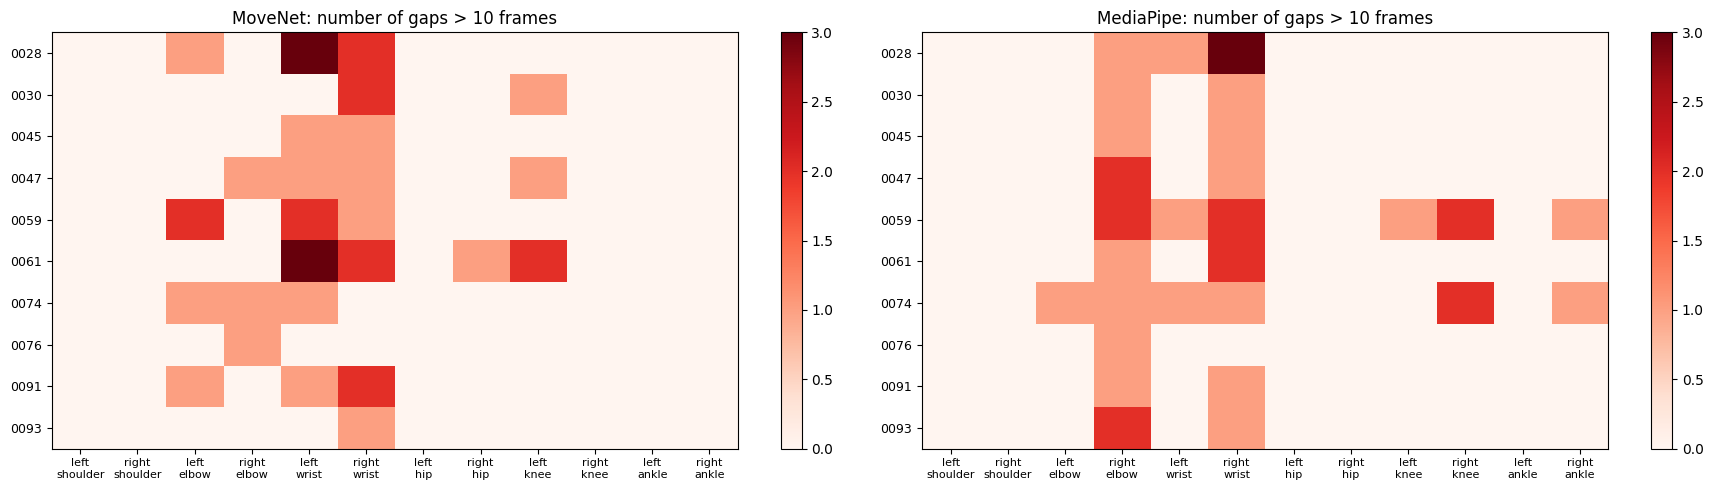

In [144]:
fig, axes = plt.subplots(1, 2, figsize=(18, 5))

for ax, df_gaps, title in zip(axes, [movenet_gaps[JOINTS], mediapipe_gaps[JOINTS]], ['MoveNet', 'MediaPipe']):
    im = ax.imshow(df_gaps.values, aspect='auto', cmap='Reds')
    ax.set_xticks(range(len(JOINTS)))
    ax.set_xticklabels([j.replace('_', '\n') for j in JOINTS], fontsize=8)
    ax.set_yticks(range(len(df_gaps)))
    ax.set_yticklabels([n.split('_')[2] for n in df_gaps.index], fontsize=9)
    ax.set_title(f'{title}: number of gaps > {MAX_INTERP_GAP} frames')
    plt.colorbar(im, ax=ax)

plt.tight_layout()
plt.show()

### Which joints are most unreliable?
Percentage of frames with confidence < 0.6 per joint, across all videos.

,MediaPipe low_conf_%,MoveNet low_conf_%,MediaPipe reliable_%,MoveNet reliable_%
joint,,,,
right_wrist,57.4,53.3,42.6,46.7
left_wrist,9.8,49.9,90.2,50.1
left_elbow,2.4,26.3,97.6,73.7
left_knee,3.8,20.9,96.2,79.1
right_elbow,72.3,18.9,27.7,81.1
right_hip,0.0,10.8,100.0,89.2
right_shoulder,0.0,3.6,100.0,96.4
left_hip,0.0,2.9,100.0,97.1
right_ankle,10.2,2.7,89.8,97.3


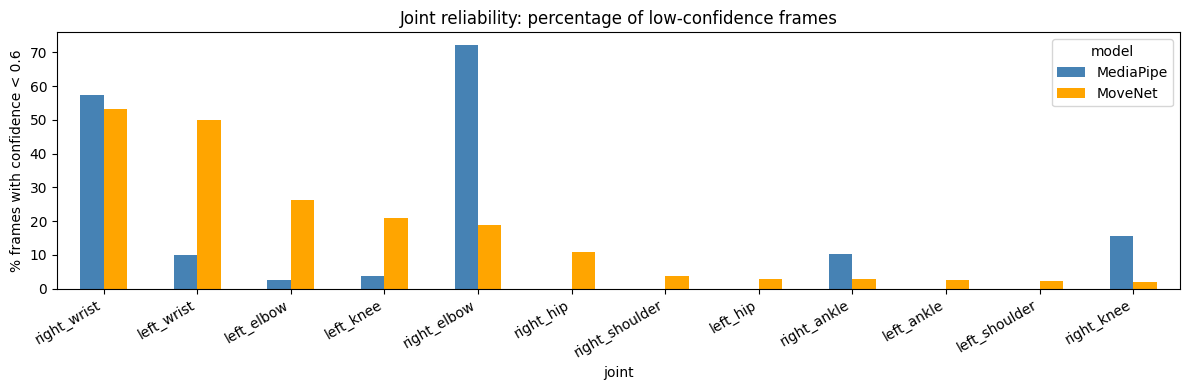

In [145]:
rows = []
for joint in JOINTS:
    for name, cropped_dict, metric in [('MoveNet', movenet_cropped, 'confidence'), ('MediaPipe', mediapipe_cropped, 'visibility')]:
        total = sum(len(df) for df in cropped_dict.values())
        low   = sum((df[f'{joint}_{metric}'] < THRESHOLD).sum() for df in cropped_dict.values())
        rows.append({'joint': joint, 'model': name, 'low_conf_%': round(100 * low / total, 1), 'reliable_%': round(100 * (total - low) / total, 1)})

df_rel = pd.DataFrame(rows)

reliability = df_rel.pivot(index='joint', columns='model', values=['low_conf_%', 'reliable_%'])
reliability.columns = [f'{model} {col}' for col, model in reliability.columns]
reliability = reliability.sort_values('MoveNet low_conf_%', ascending=False)
display(reliability)

df_rel.pivot(index='joint', columns='model', values='low_conf_%').reindex(reliability.index).plot(
    kind='bar', figsize=(12, 4), color=['steelblue', 'orange']
)
plt.ylabel('% frames with confidence < 0.6')
plt.title('Joint reliability: percentage of low-confidence frames')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

**MediaPipe is more stable in upper body and hips. MoveNet has more gaps overall but they are shorter and easier to interpolate.**

### Gap length distribution
How are gap lengths distributed across all joints and videos? This shows whether most gaps are short (fixable) or long (unfixable).

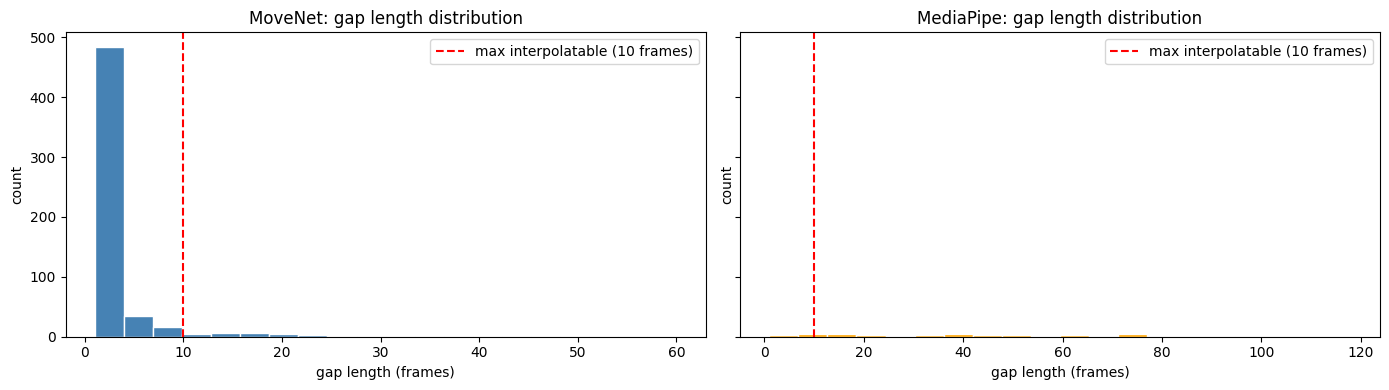

MoveNet   total gaps: 576, mean: 3.4, median: 1, max: 60
MediaPipe total gaps: 42, mean: 40.4, median: 38, max: 118


In [146]:
mn_lengths = [g[1] - g[0] for df in movenet_cropped.values()
              for gaps in find_gaps(df, 'confidence').values() for g in gaps]
mp_lengths = [g[1] - g[0] for df in mediapipe_cropped.values()
              for gaps in find_gaps(df, 'visibility').values() for g in gaps]

fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)

for ax, lengths, title, color in zip(axes, [mn_lengths, mp_lengths], ['MoveNet', 'MediaPipe'], ['steelblue', 'orange']):
    ax.hist(lengths, bins=20, color=color, edgecolor='white')
    ax.axvline(MAX_INTERP_GAP, color='red', linestyle='--', label=f'max interpolatable ({MAX_INTERP_GAP} frames)')
    ax.set_xlabel('gap length (frames)')
    ax.set_ylabel('count')
    ax.set_title(f'{title}: gap length distribution')
    ax.legend()

plt.tight_layout()
plt.show()

print(f'MoveNet   total gaps: {len(mn_lengths)}, mean: {np.mean(mn_lengths):.1f}, median: {np.median(mn_lengths):.0f}, max: {max(mn_lengths)}')
print(f'MediaPipe total gaps: {len(mp_lengths)}, mean: {np.mean(mp_lengths):.1f}, median: {np.median(mp_lengths):.0f}, max: {max(mp_lengths)}')

### Statistical comparison between models
Mann-Whitney U test on gap lengths: are the gap distributions significantly different between MoveNet and MediaPipe?

In [147]:
from scipy import stats

stat, p = stats.mannwhitneyu(mn_lengths, mp_lengths, alternative='two-sided')

print(f'MoveNet  gaps: {len(mn_lengths)}, mean length: {np.mean(mn_lengths):.1f} frames')
print(f'MediaPipe gaps: {len(mp_lengths)}, mean length: {np.mean(mp_lengths):.1f} frames')
print()
print(f'Mann-Whitney U = {stat:.0f}, p = {p:.4f}')
print('Significant difference (p < 0.05):' , p < 0.05)

MoveNet  gaps: 576, mean length: 3.4 frames
MediaPipe gaps: 42, mean length: 40.4 frames

Mann-Whitney U = 1047, p = 0.0000
Significant difference (p < 0.05): True


### Do short gaps have valid anchor points?
For interpolation to work, there must be a reliable frame on both sides of the gap.
Interior gaps always have this. Boundary gaps (at the start or end of the clip) may not.

In [148]:
for name, cropped_dict, metric in [('MoveNet', movenet_cropped, 'confidence'), ('MediaPipe', mediapipe_cropped, 'visibility')]:
    interior = boundary = 0
    for df in cropped_dict.values():
        n = len(df)
        for gaps in find_gaps(df, metric, max_gap_size=MAX_INTERP_GAP).values():
            for start, end in gaps:
                if (start == 0) or (end == n):
                    boundary += 1
                else:
                    interior += 1
    print(f'{name}: {interior + boundary} short gaps  {interior} interior, {boundary} at boundary')

MoveNet: 539 short gaps  511 interior, 28 at boundary
MediaPipe: 5 short gaps  2 interior, 3 at boundary


### Boundary analysis
For joints that are low-confidence at the clip edge, check if a reliable frame exists nearby in the full video.

In [149]:
def boundary_analysis(cropped_dict, full_dict, metric):
    rows = []
    for video, df_crop in cropped_dict.items():
        first_frame = df_crop['frame'].iloc[0]
        last_frame  = df_crop['frame'].iloc[-1]
        df_full     = full_dict.get(video)
        for joint in JOINTS:
            col        = f'{joint}_{metric}'
            conf_first = df_crop[col].iloc[0]
            conf_last  = df_crop[col].iloc[-1]
            low_first  = conf_first < THRESHOLD
            low_last   = conf_last  < THRESHOLD
            if not (low_first or low_last):
                continue
            dist_before = dist_after = None
            if df_full is not None:
                frames = df_full['frame'].values
                good   = frames[df_full[col].values >= THRESHOLD]
                before = good[good < first_frame]
                after  = good[good > last_frame]
                dist_before = int(first_frame - before[-1]) if len(before) else None
                dist_after  = int(after[0] - last_frame)    if len(after)  else None
            rows.append({
                'video': video, 'joint': joint,
                'low_first': low_first, 'conf_first': round(conf_first, 3),
                'low_last':  low_last,  'conf_last':  round(conf_last,  3),
                'dist_before': dist_before, 'dist_after': dist_after,
                'can_interp_before': low_first and dist_before is not None and dist_before <= MAX_INTERP_GAP,
                'can_interp_after':  low_last  and dist_after  is not None and dist_after  <= MAX_INTERP_GAP,
            })
    return pd.DataFrame(rows)

movenet_boundary   = boundary_analysis(movenet_cropped,   movenet_full,   'confidence')
mediapipe_boundary = boundary_analysis(mediapipe_cropped, mediapipe_full, 'visibility')

print('MoveNet boundary joints')
display(movenet_boundary)
print('MediaPipe boundary joints')
display(mediapipe_boundary)

MoveNet boundary joints


,video,joint,low_first,conf_first,low_last,conf_last,dist_before,dist_after,can_interp_before,can_interp_after
0,DJI_20250425092743_0028_D_movenet,left_elbow,True,0.585,True,0.427,3.0,31.0,True,False
1,DJI_20250425092743_0028_D_movenet,left_wrist,True,0.409,True,0.476,NaN,34.0,False,False
2,DJI_20250425092743_0028_D_movenet,right_wrist,True,0.475,True,0.451,296.0,16.0,False,False
3,DJI_20250425093100_0030_D_movenet,left_shoulder,True,0.549,False,0.842,1.0,1.0,True,False
4,DJI_20250425093100_0030_D_movenet,right_elbow,True,0.455,False,0.659,1.0,1.0,True,False
5,DJI_20250425093100_0030_D_movenet,left_wrist,True,0.516,False,0.760,1.0,1.0,True,False
6,DJI_20250425093100_0030_D_movenet,right_wrist,True,0.510,True,0.598,20.0,1.0,False,True
7,DJI_20250425093100_0030_D_movenet,right_hip,True,0.577,False,0.839,1.0,1.0,True,False
8,DJI_20250425093100_0030_D_movenet,left_knee,True,0.329,False,0.713,52.0,1.0,False,False
9,DJI_20250425093100_0030_D_movenet,right_ankle,True,0.522,False,0.677,1.0,1.0,True,False


MediaPipe boundary joints


,video,joint,low_first,conf_first,low_last,conf_last,dist_before,dist_after,can_interp_before,can_interp_after
0,DJI_20250425092743_0028_D_mediapipe_norm,right_elbow,True,0.369,True,0.229,NaN,757.0,False,False
1,DJI_20250425092743_0028_D_mediapipe_norm,right_wrist,True,0.266,True,0.351,NaN,38.0,False,False
2,DJI_20250425092743_0028_D_mediapipe_norm,right_knee,False,0.687,True,0.552,1.0,32.0,False,False
3,DJI_20250425093100_0030_D_mediapipe_norm,right_elbow,False,0.651,True,0.500,1.0,30.0,False,False
4,DJI_20250425104507_0045_D_mediapipe_norm,right_elbow,True,0.164,True,0.208,NaN,NaN,False,False
5,DJI_20250425104507_0045_D_mediapipe_norm,right_wrist,True,0.078,True,0.283,NaN,24.0,False,False
6,DJI_20250425104804_0047_D_mediapipe_norm,right_elbow,True,0.527,True,0.419,NaN,77.0,False,False
7,DJI_20250425104804_0047_D_mediapipe_norm,right_wrist,True,0.576,False,0.936,15.0,1.0,False,False
8,DJI_20250425112502_0059_D_mediapipe_norm,right_elbow,True,0.427,True,0.398,NaN,47.0,False,False
9,DJI_20250425112502_0059_D_mediapipe_norm,left_wrist,True,0.502,False,0.803,NaN,1.0,False,False


### Summary

In [150]:
for gaps_df, boundary_df, name, metric in [
    (movenet_gaps,   movenet_boundary,   'MoveNet',   'confidence'),
    (mediapipe_gaps, mediapipe_boundary, 'MediaPipe', 'visibility'),
]:
    print('=' * 50)
    print(f'{name} | threshold: {THRESHOLD} | metric: {metric}')
    print('=' * 50)
    print(f'Gaps > {MAX_INTERP_GAP} frames (will be NaN): {gaps_df["total_long_gaps"].sum()}')
    print(f'Videos affected: {(gaps_df["total_long_gaps"] > 0).sum()} / {len(gaps_df)}')
    print(f'Boundary joints with low confidence: {len(boundary_df)}')
    print(f'  Fixable at start: {boundary_df["can_interp_before"].sum()}')
    print(f'  Fixable at end:   {boundary_df["can_interp_after"].sum()}')
    print()

MoveNet | threshold: 0.6 | metric: confidence
Gaps > 10 frames (will be NaN): 37
Videos affected: 10 / 10
Boundary joints with low confidence: 38
  Fixable at start: 18
  Fixable at end:   10

MediaPipe | threshold: 0.6 | metric: visibility
Gaps > 10 frames (will be NaN): 37
Videos affected: 10 / 10
Boundary joints with low confidence: 27
  Fixable at start: 1
  Fixable at end:   0



## Part B: Linear Interpolation

Strategy:
1. Find frames where confidence < 0.6
2. Group them into consecutive gaps
3. Gaps up to 10 frames with anchor points on both sides: fill using linear interpolation
4. All other low-confidence frames: set x and y to NaN

In [151]:
def find_low_confidence_gaps(confidence_values, threshold, max_gap_size):
    n      = len(confidence_values)
    low    = confidence_values < threshold
    padded = np.pad(low, (1, 1), constant_values=False)
    diff   = np.diff(padded.astype(int))
    gaps   = []
    for start, end in zip(np.where(diff == 1)[0], np.where(diff == -1)[0]):
        can_interpolate = (end - start <= max_gap_size) and (start > 0) and (end < n)
        gaps.append((start, end, can_interpolate))
    return gaps


def interpolate_keypoints(df, threshold, max_gap_size):
    df      = df.copy().reset_index(drop=True)
    summary = []

    for joint in JOINTS:
        conf_col   = f'{joint}_confidence'
        flag_col   = f'{joint}_interpolated'
        orig_conf  = df[conf_col].values.copy()   # keep original confidence untouched
        df[flag_col] = False

        for start, end, can_interpolate in find_low_confidence_gaps(orig_conf, threshold, max_gap_size):
            gap_length = end - start
            if can_interpolate:
                for coord in ['x', 'y']:
                    col = f'{joint}_{coord}'
                    df.loc[start:end - 1, col] = np.linspace(df.at[start - 1, col], df.at[end, col], gap_length + 2)[1:-1]
                df.loc[start:end - 1, flag_col] = True
                summary.append({'joint': joint, 'length': gap_length, 'action': 'INTERPOLATED'})
            else:
                reason = 'too long' if gap_length > max_gap_size else 'boundary'
                summary.append({'joint': joint, 'length': gap_length, 'action': f'SKIPPED ({reason})'})

        # NaN only for frames that are still low-confidence and were not interpolated
        still_low = (orig_conf < threshold) & (~df[flag_col])
        df.loc[still_low, f'{joint}_x'] = np.nan
        df.loc[still_low, f'{joint}_y'] = np.nan

    return df, pd.DataFrame(summary)

### Apply to all videos and save

In [152]:
KEYPOINT_DIR = CROPPED_DIR / 'movenet'

for kp_path in sorted(KEYPOINT_DIR.glob('*.csv')):
    df_interp, summary = interpolate_keypoints(pd.read_csv(kp_path), THRESHOLD, MAX_INTERP_GAP)
    df_interp.to_csv(OUT_CSV_DIR / kp_path.name, index=False)

    skipped = summary[summary['action'].str.startswith('SKIPPED')]
    print(f'{kp_path.stem}')
    print(f'  filled: {(summary["action"] == "INTERPOLATED").sum()}  skipped: {len(skipped)}')
    for _, row in skipped.iterrows():
        print(f'    {row["joint"]}: {row["length"]} frames ({row["action"]})')
    print()

DJI_20250425092743_0028_D_movenet
  filled: 32  skipped: 8
    left_elbow: 3 frames (SKIPPED (boundary))
    left_elbow: 42 frames (SKIPPED (too long))
    left_wrist: 47 frames (SKIPPED (too long))
    left_wrist: 25 frames (SKIPPED (too long))
    left_wrist: 20 frames (SKIPPED (too long))
    right_wrist: 38 frames (SKIPPED (too long))
    right_wrist: 30 frames (SKIPPED (too long))
    right_wrist: 10 frames (SKIPPED (boundary))

DJI_20250425093100_0030_D_movenet
  filled: 83  skipped: 9
    left_shoulder: 1 frames (SKIPPED (boundary))
    right_elbow: 1 frames (SKIPPED (boundary))
    left_wrist: 1 frames (SKIPPED (boundary))
    right_wrist: 24 frames (SKIPPED (too long))
    right_wrist: 22 frames (SKIPPED (too long))
    right_wrist: 1 frames (SKIPPED (boundary))
    right_hip: 6 frames (SKIPPED (boundary))
    left_knee: 33 frames (SKIPPED (too long))
    right_ankle: 1 frames (SKIPPED (boundary))

DJI_20250425104507_0045_D_movenet
  filled: 51  skipped: 6
    left_elbow: 1 fr

### Compare original vs interpolated

- Blue: original frames with confidence >= 0.6
- Orange: filled by interpolation
- Red: too low to interpolate, set to NaN

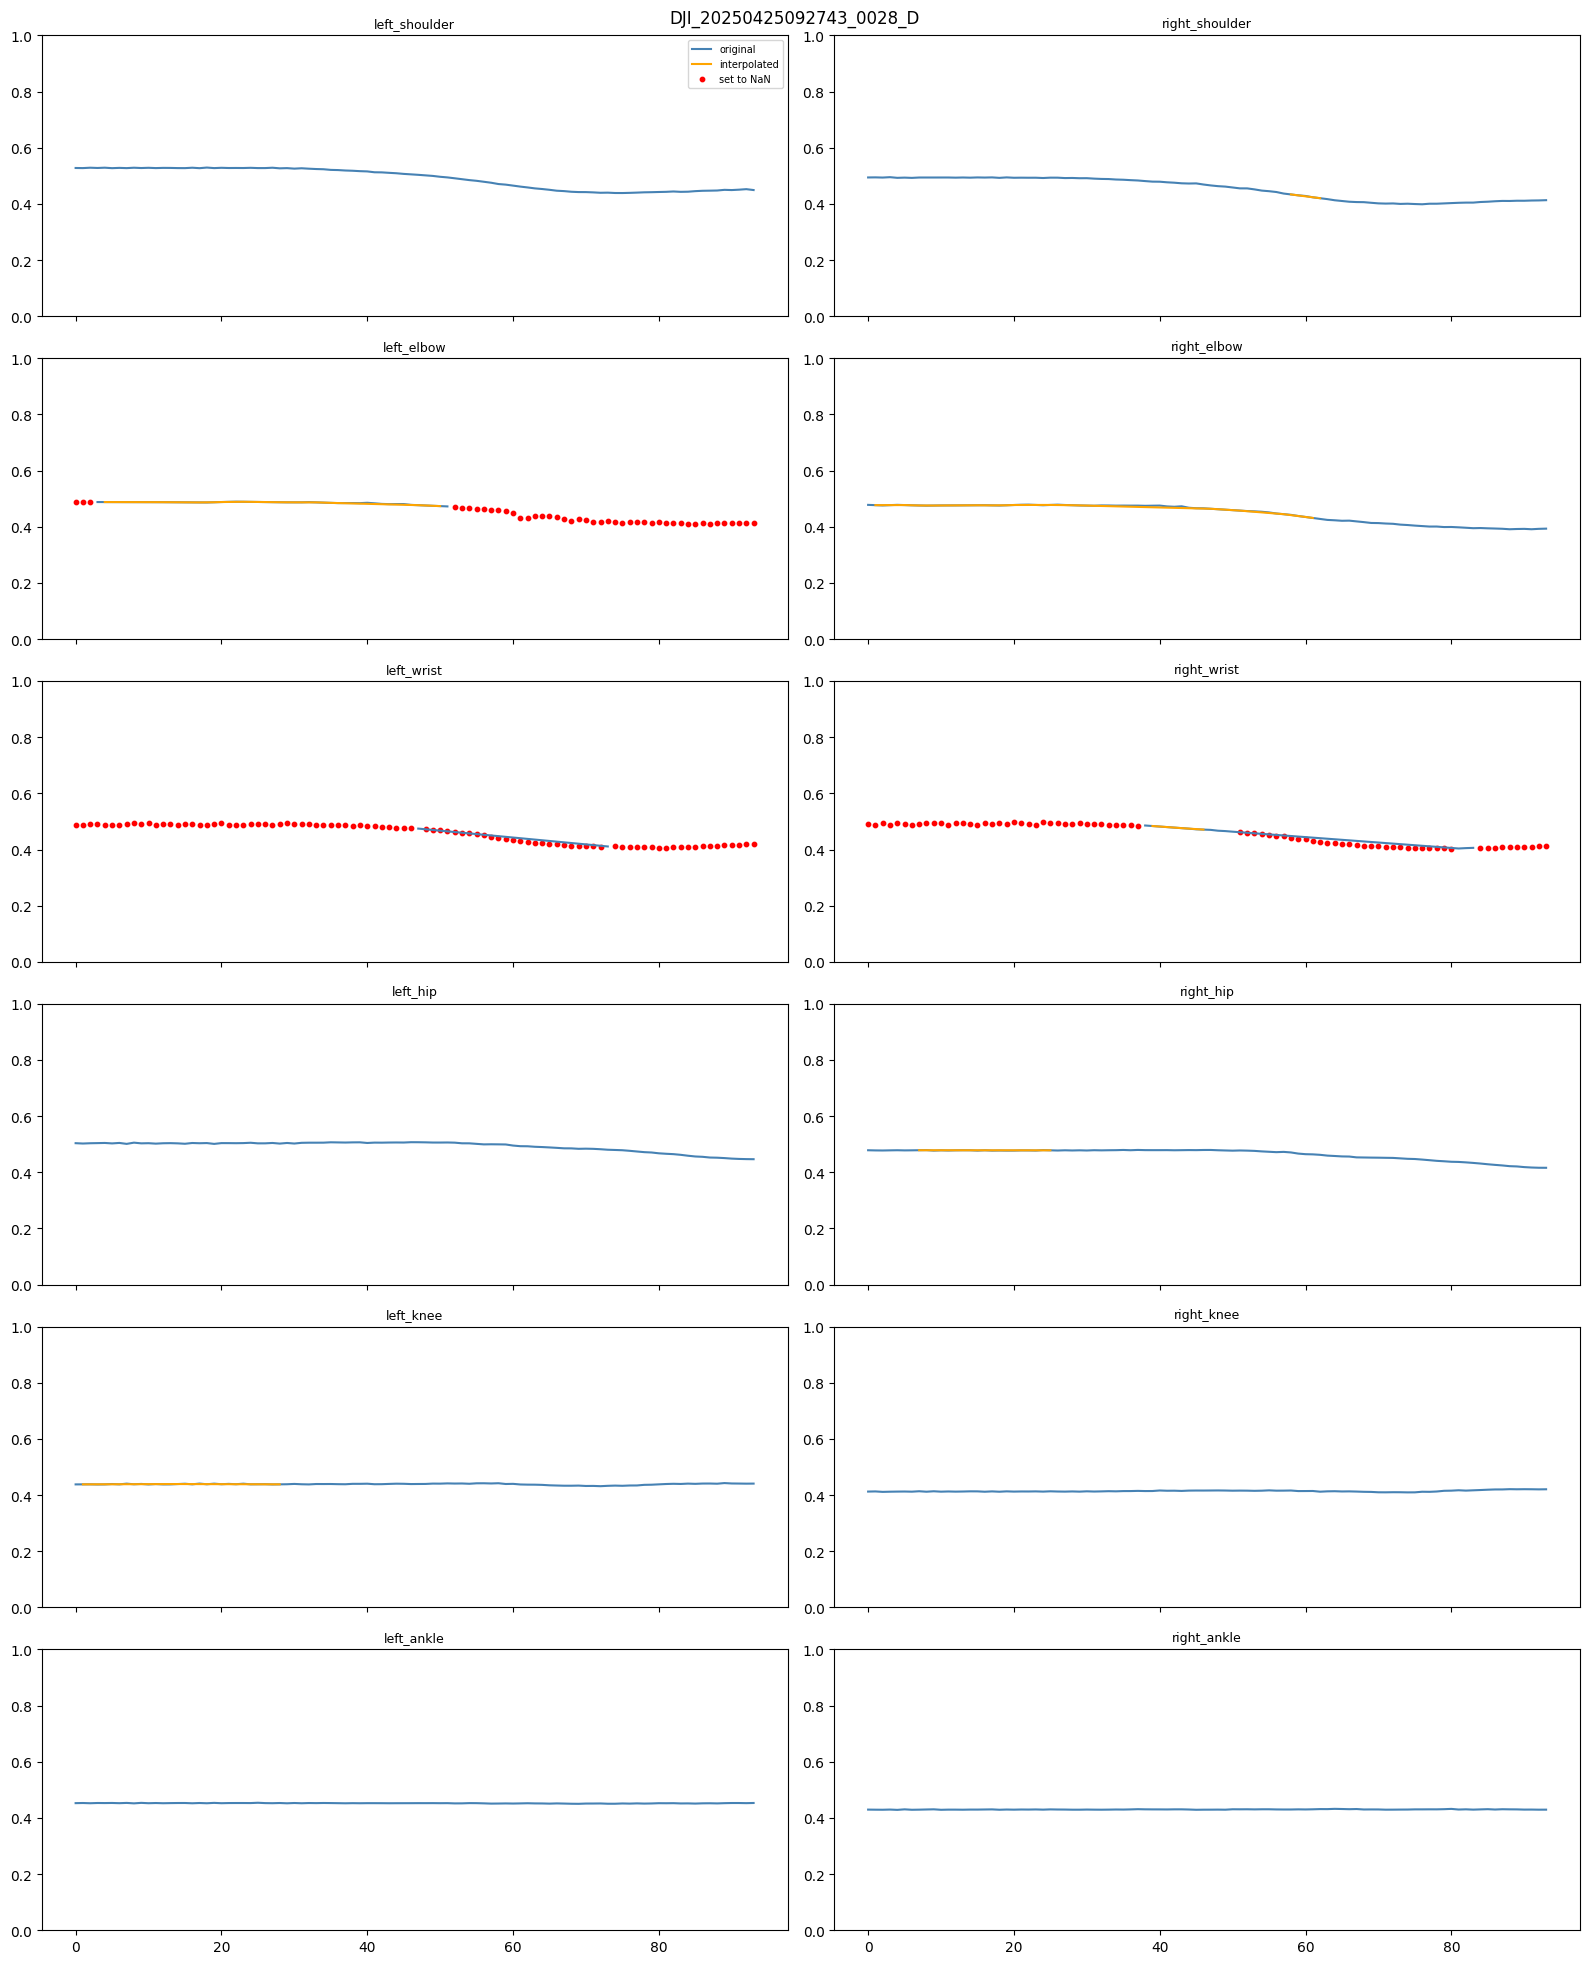

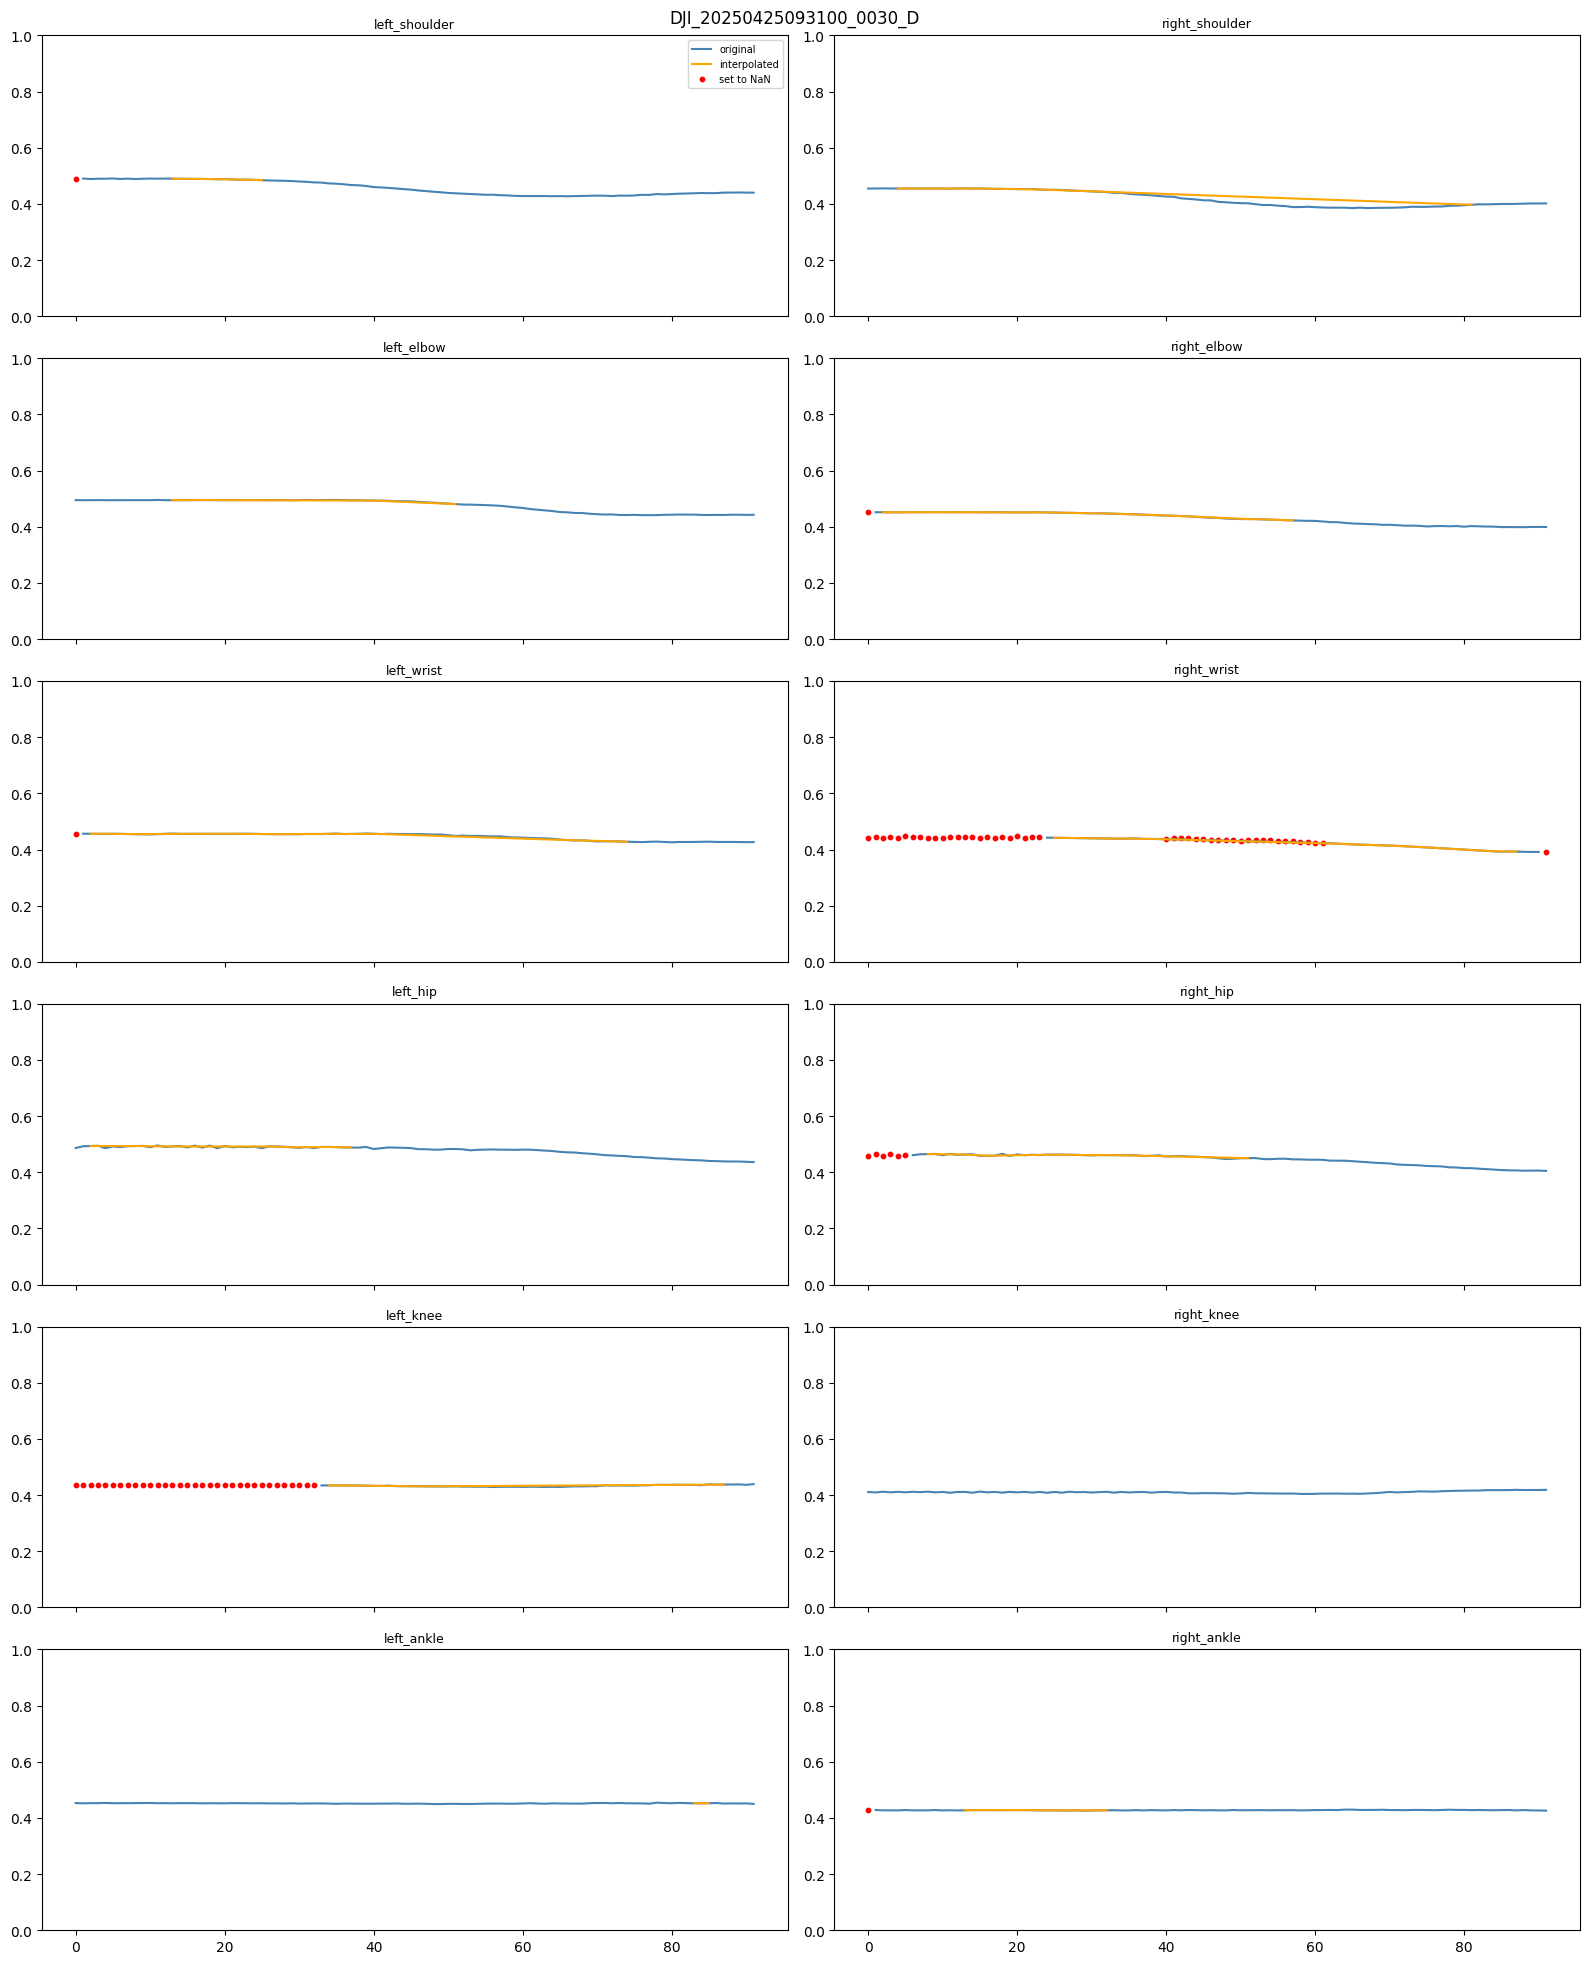

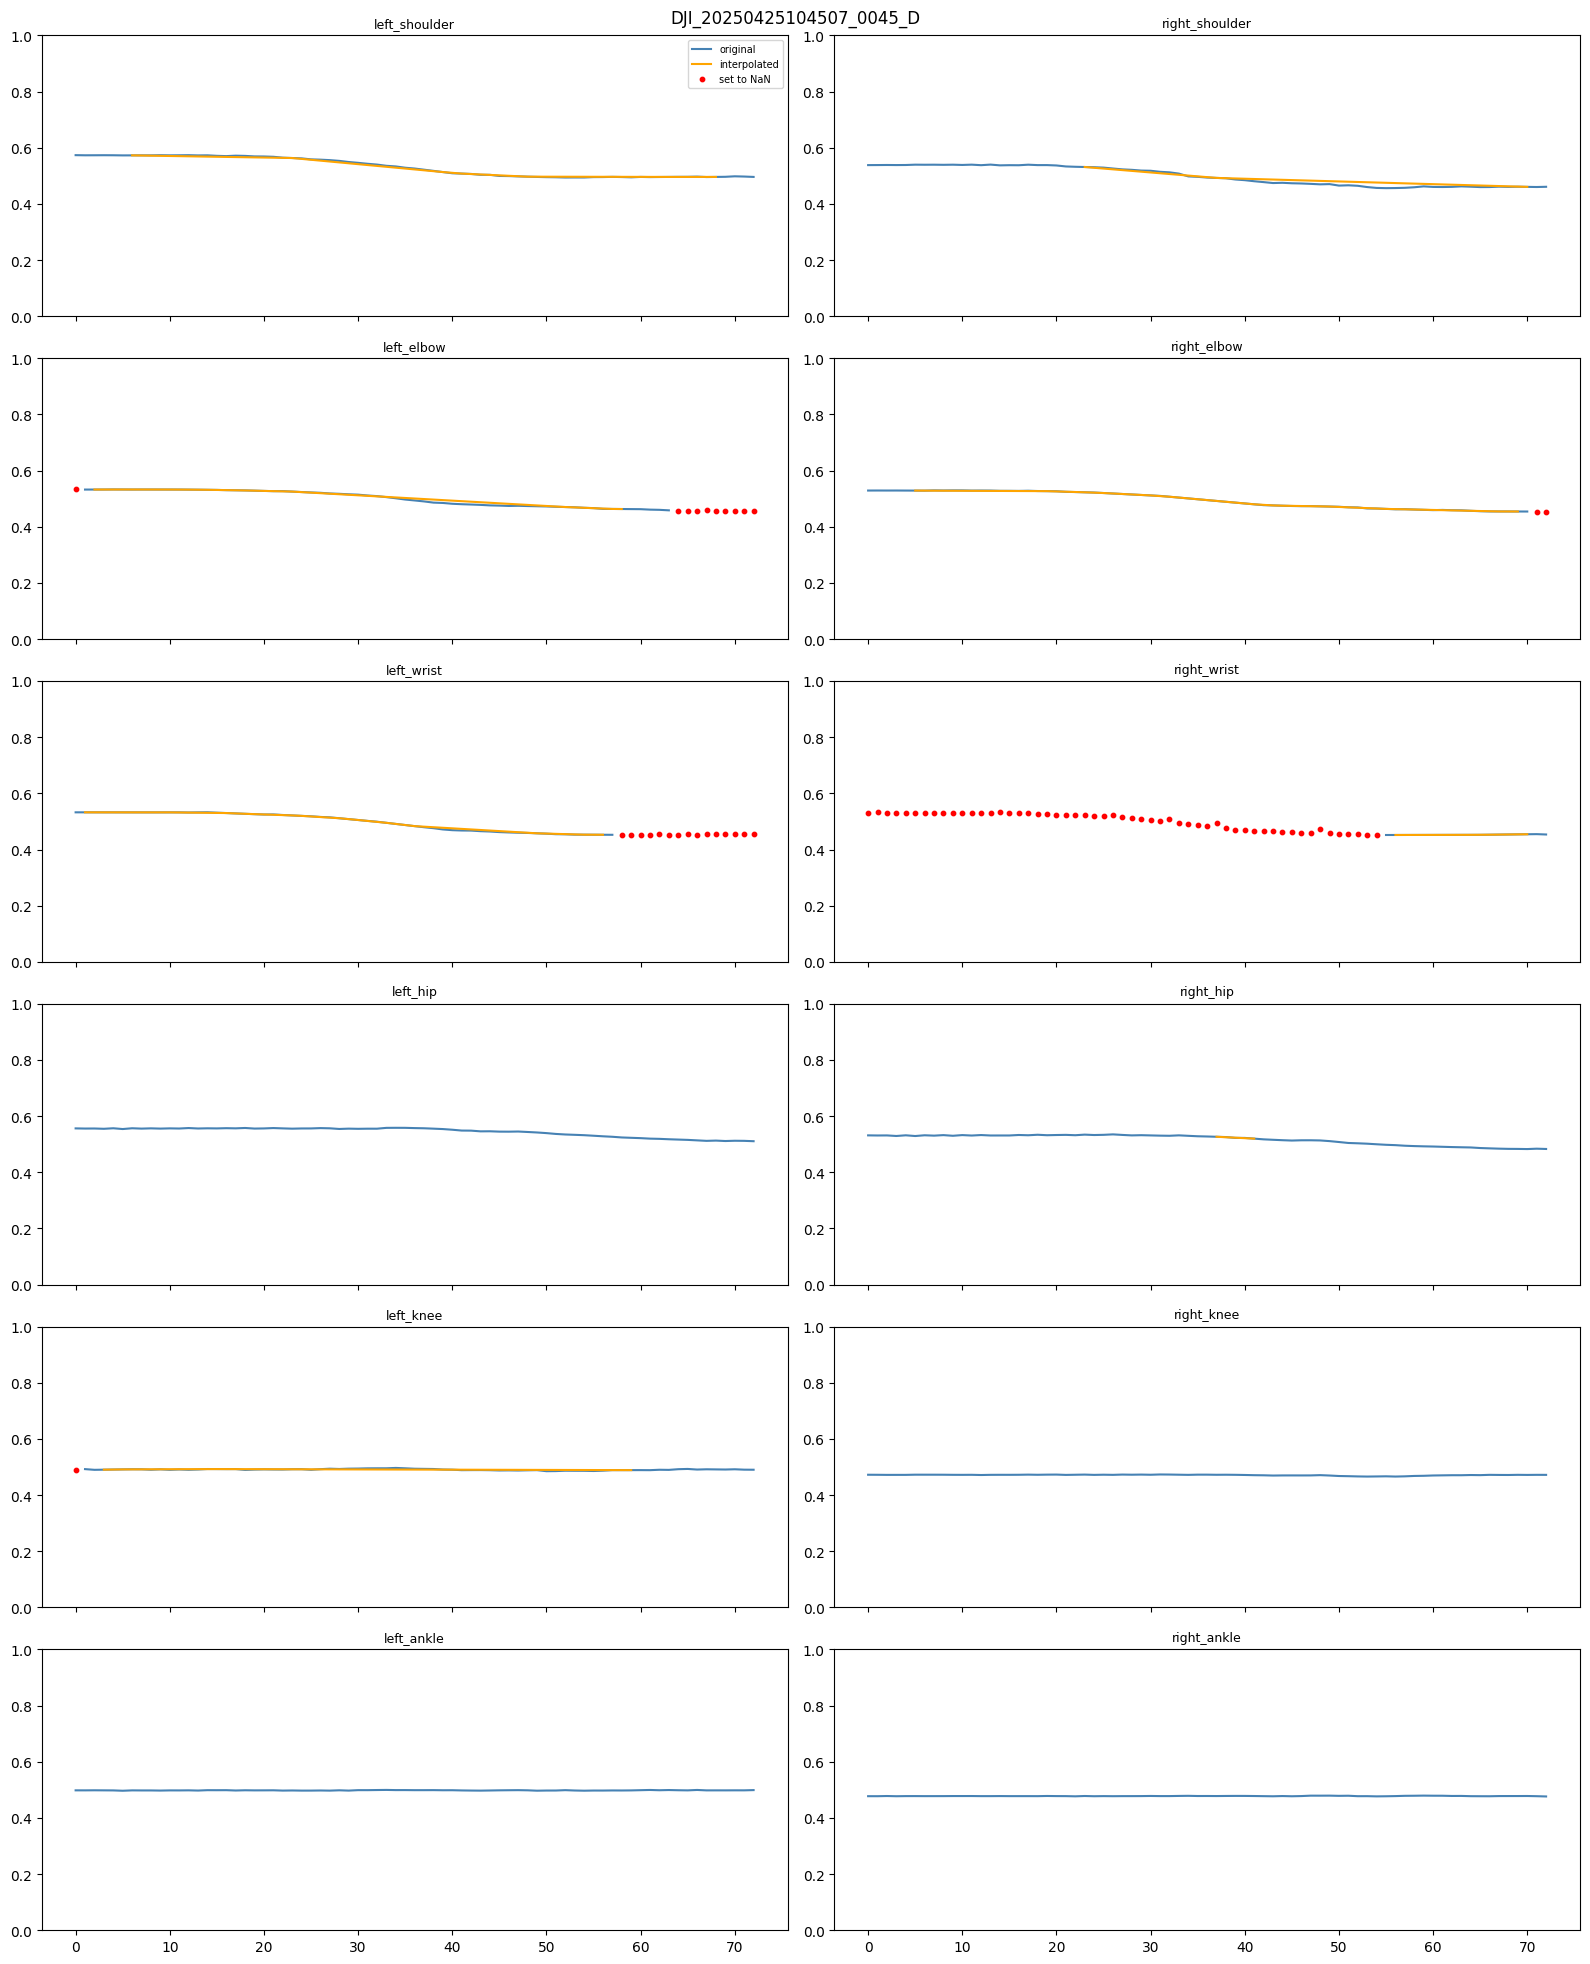

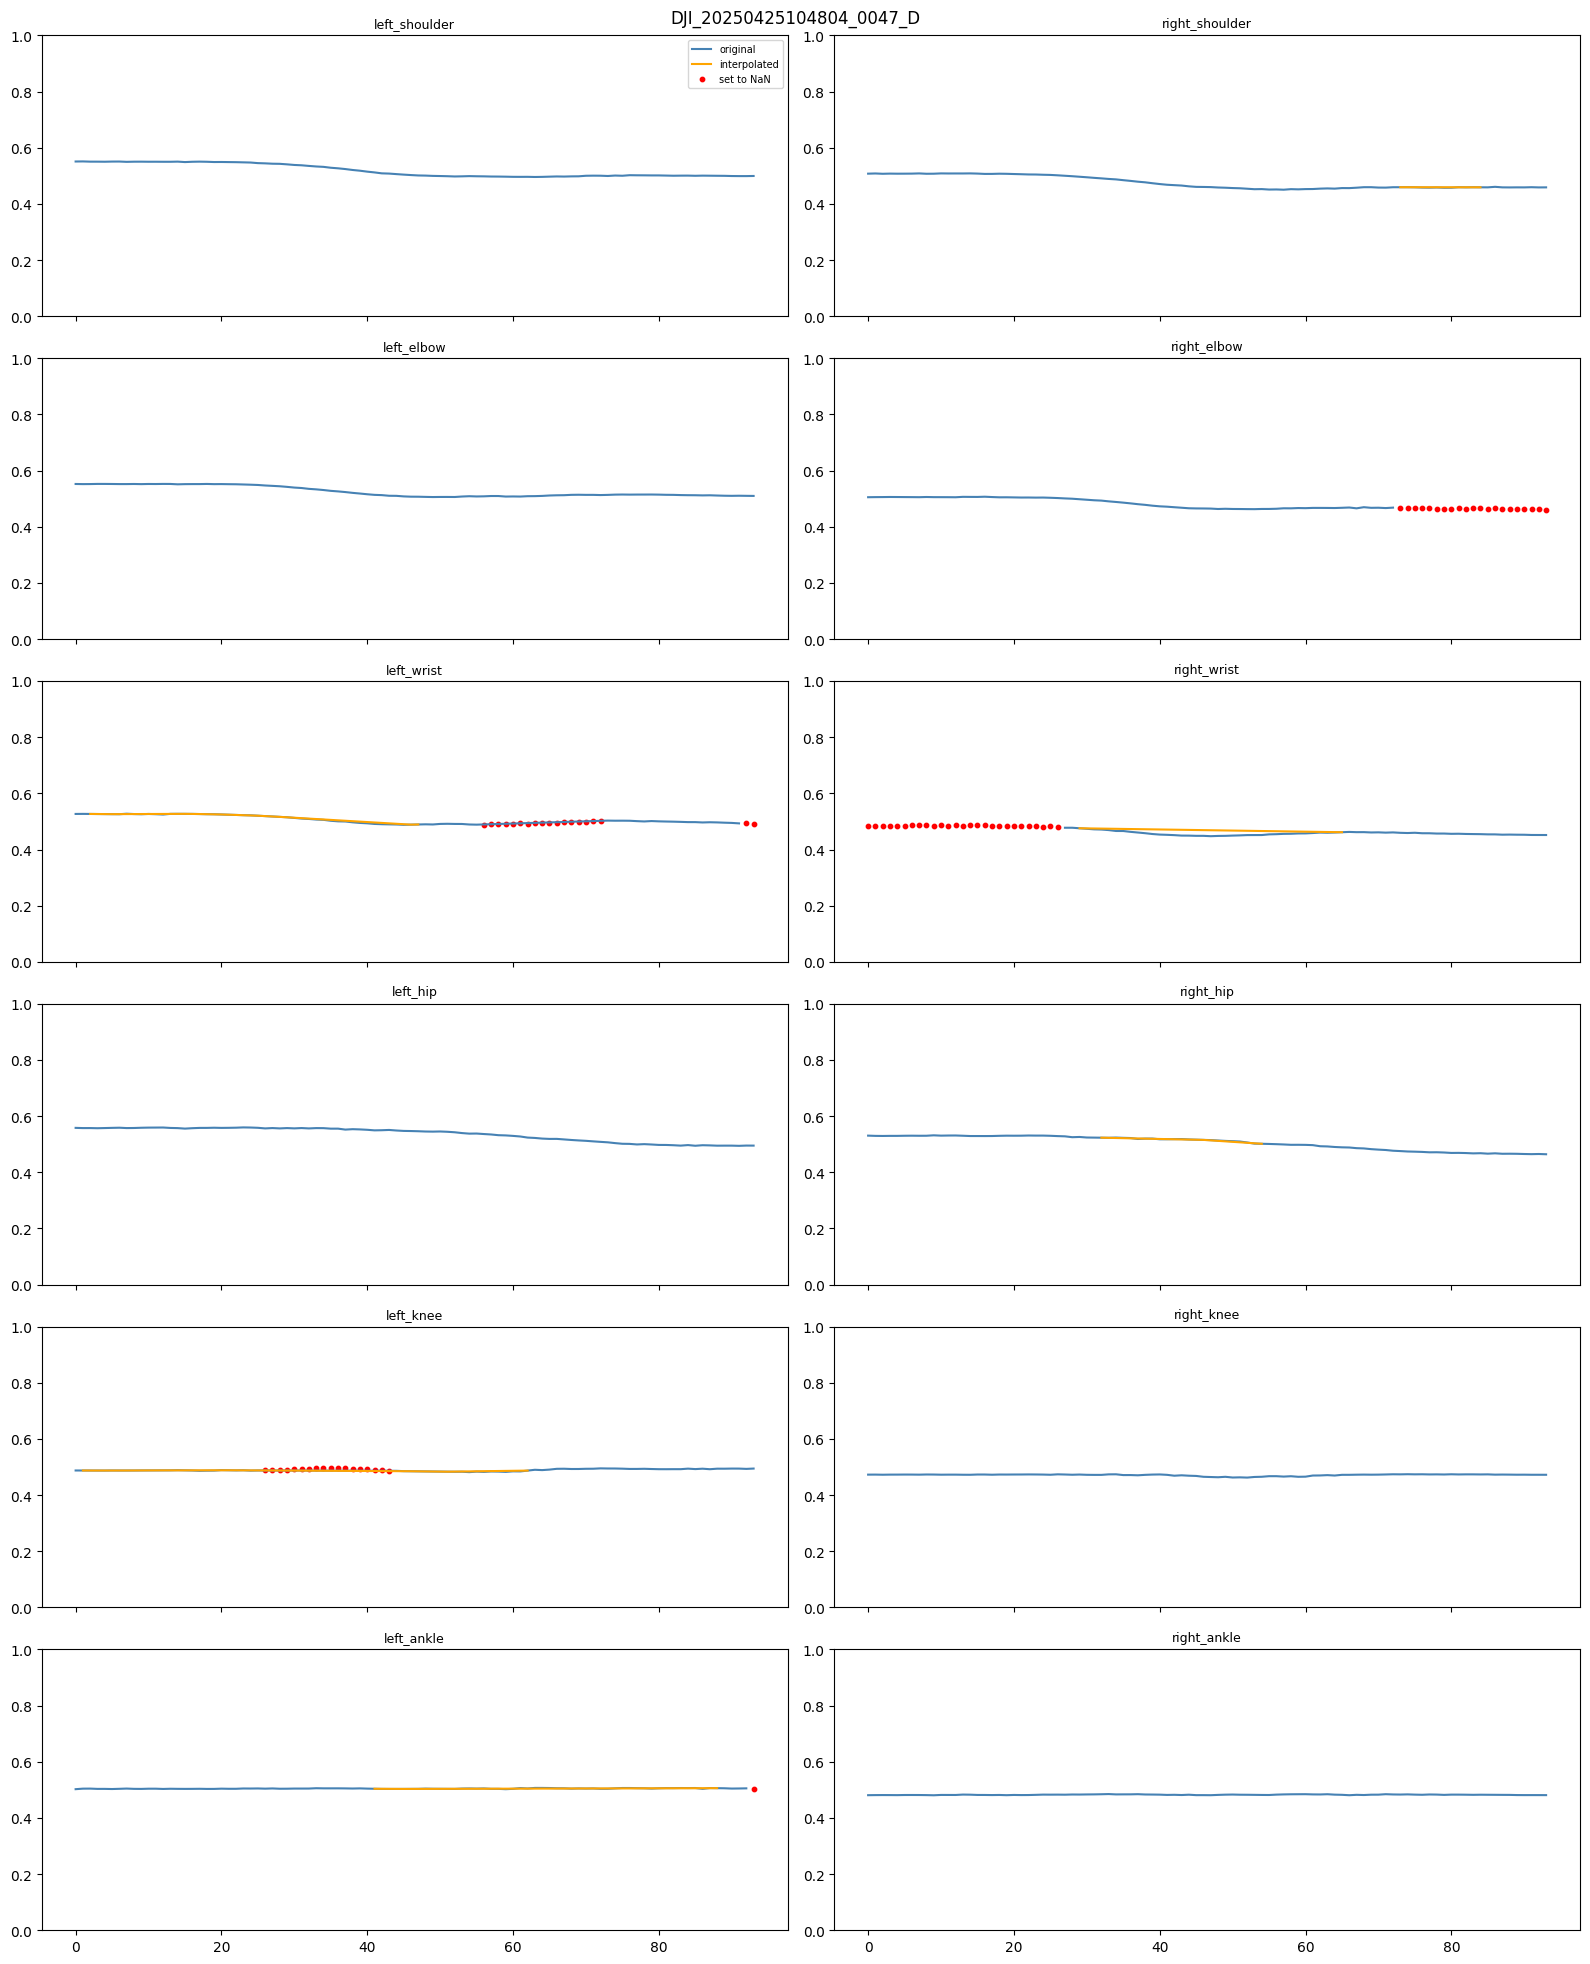

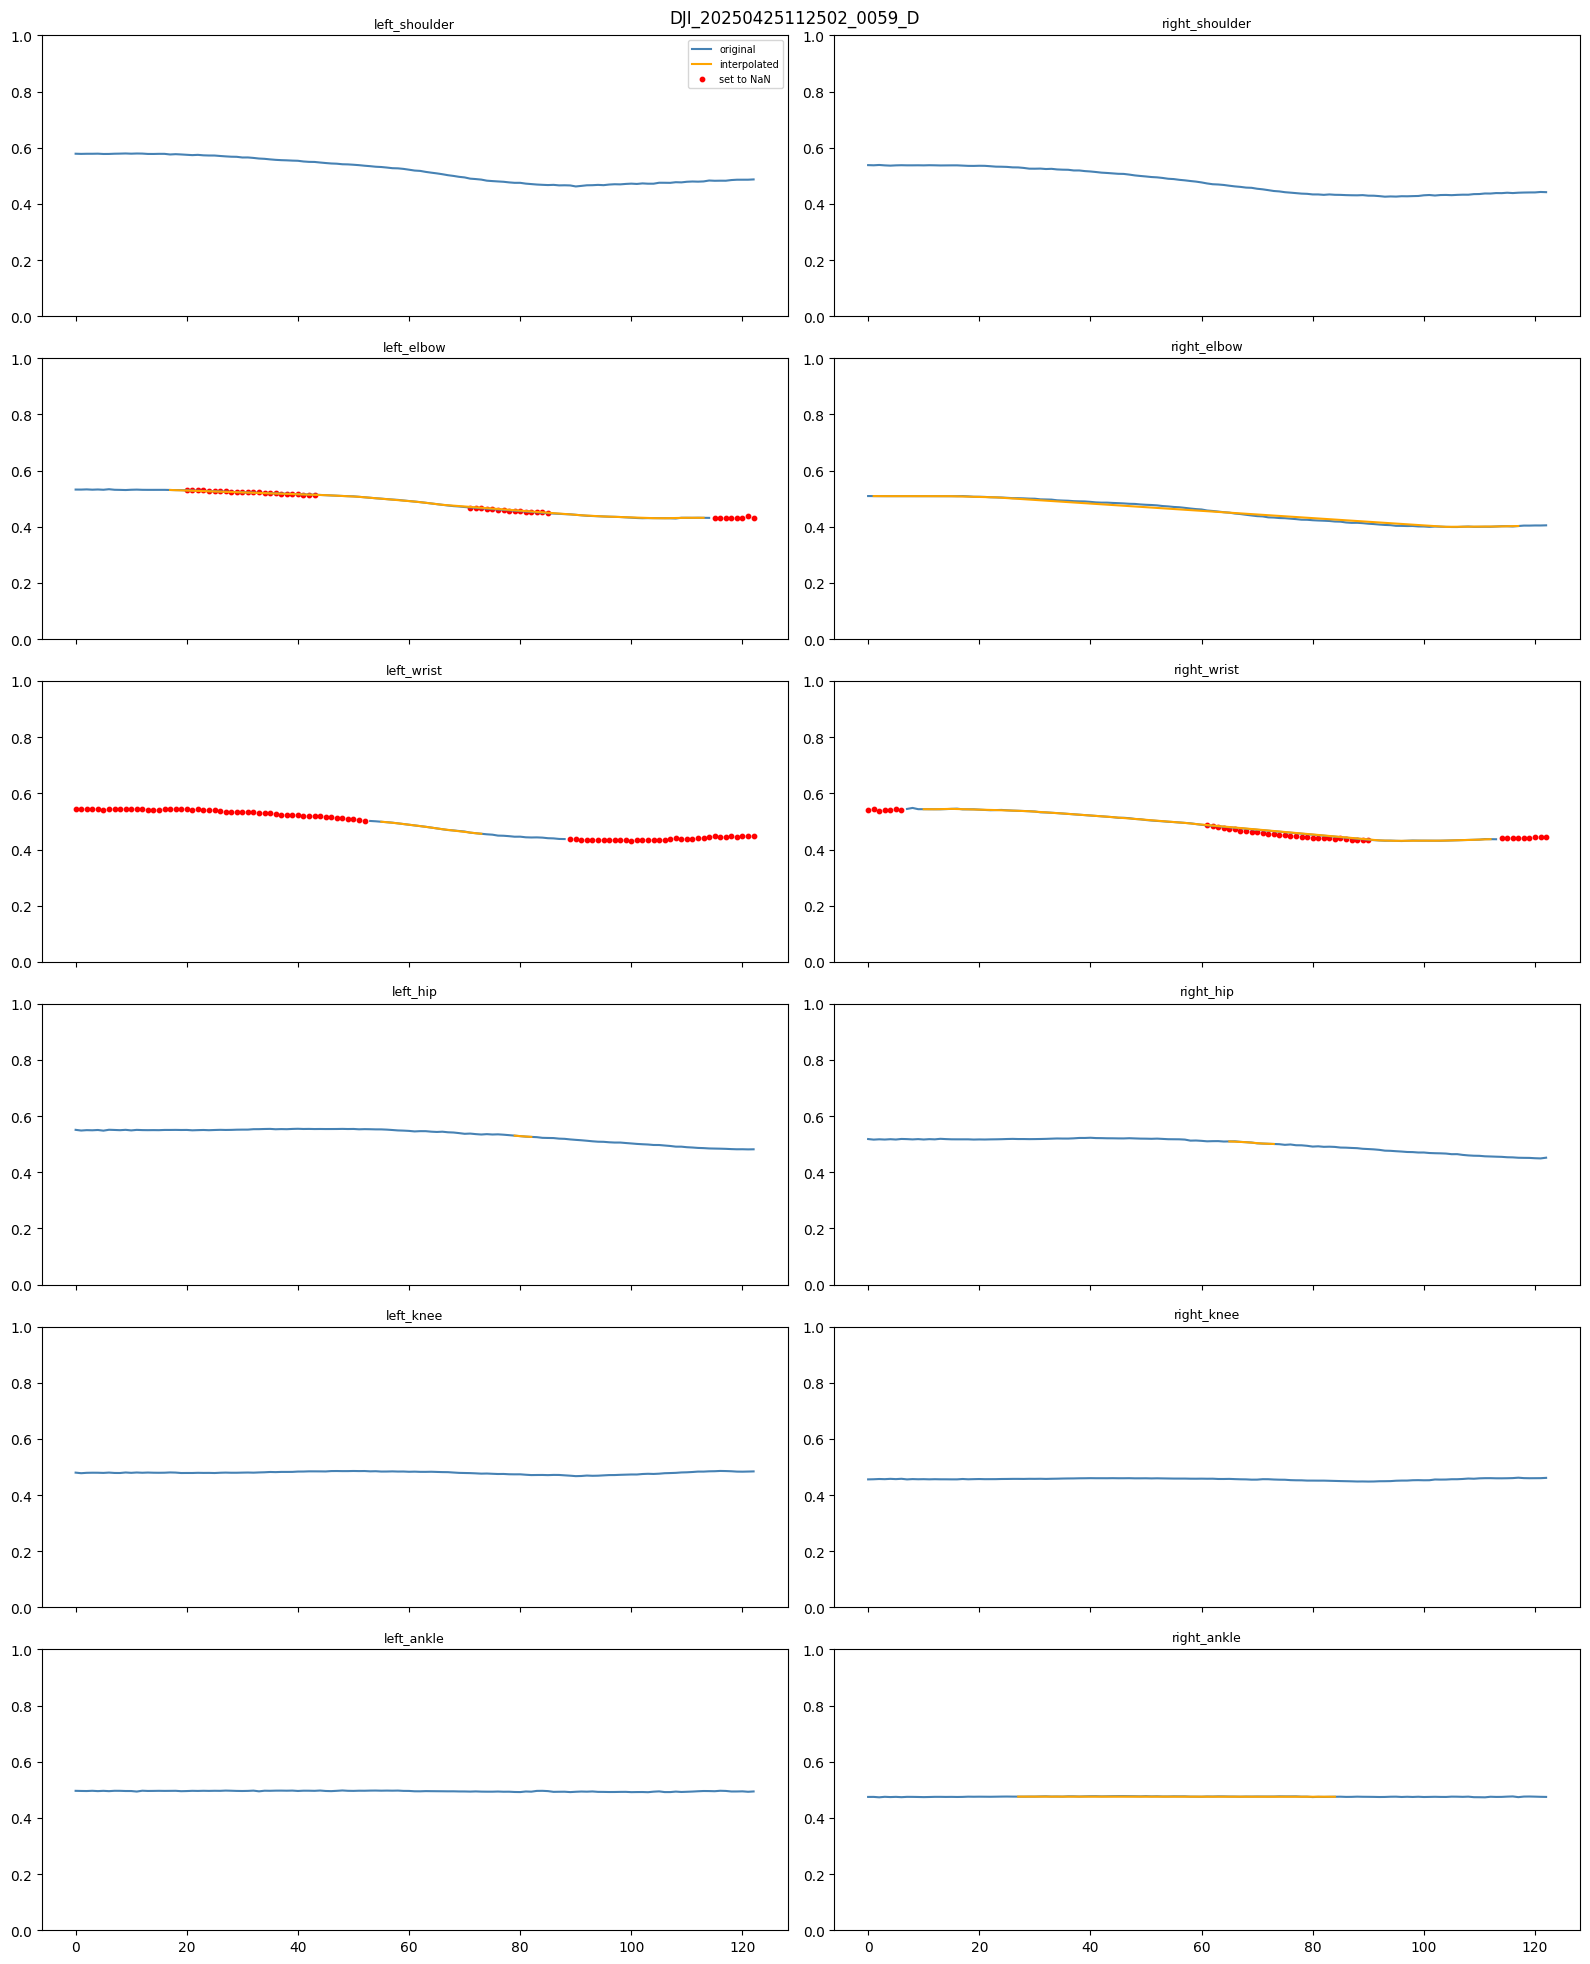

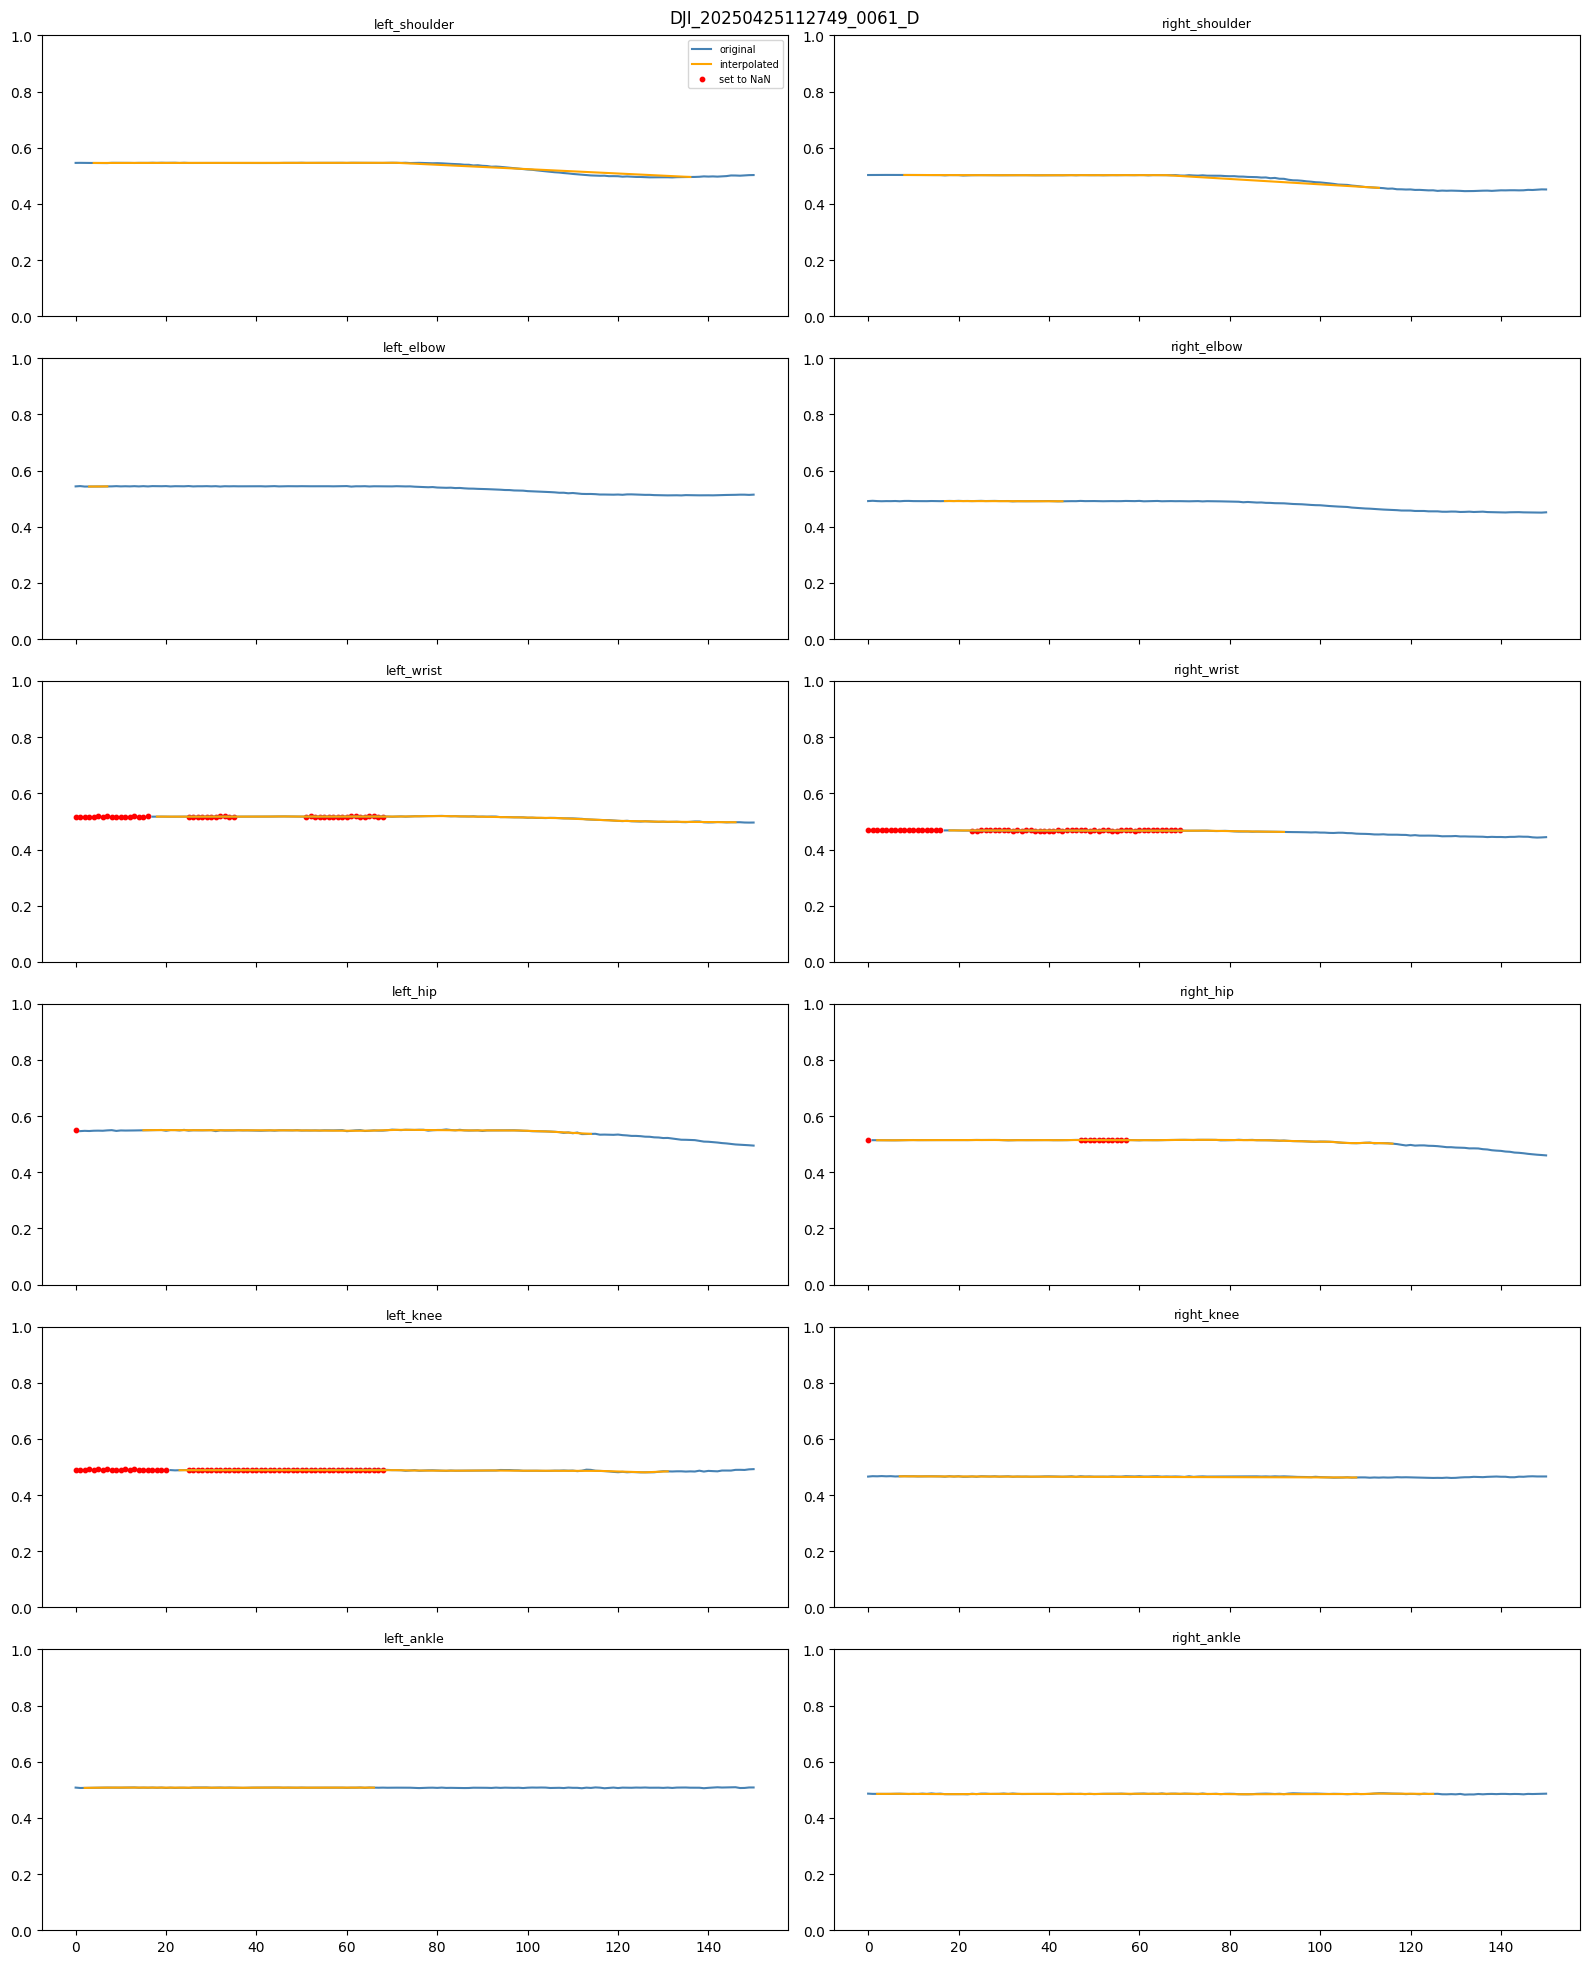

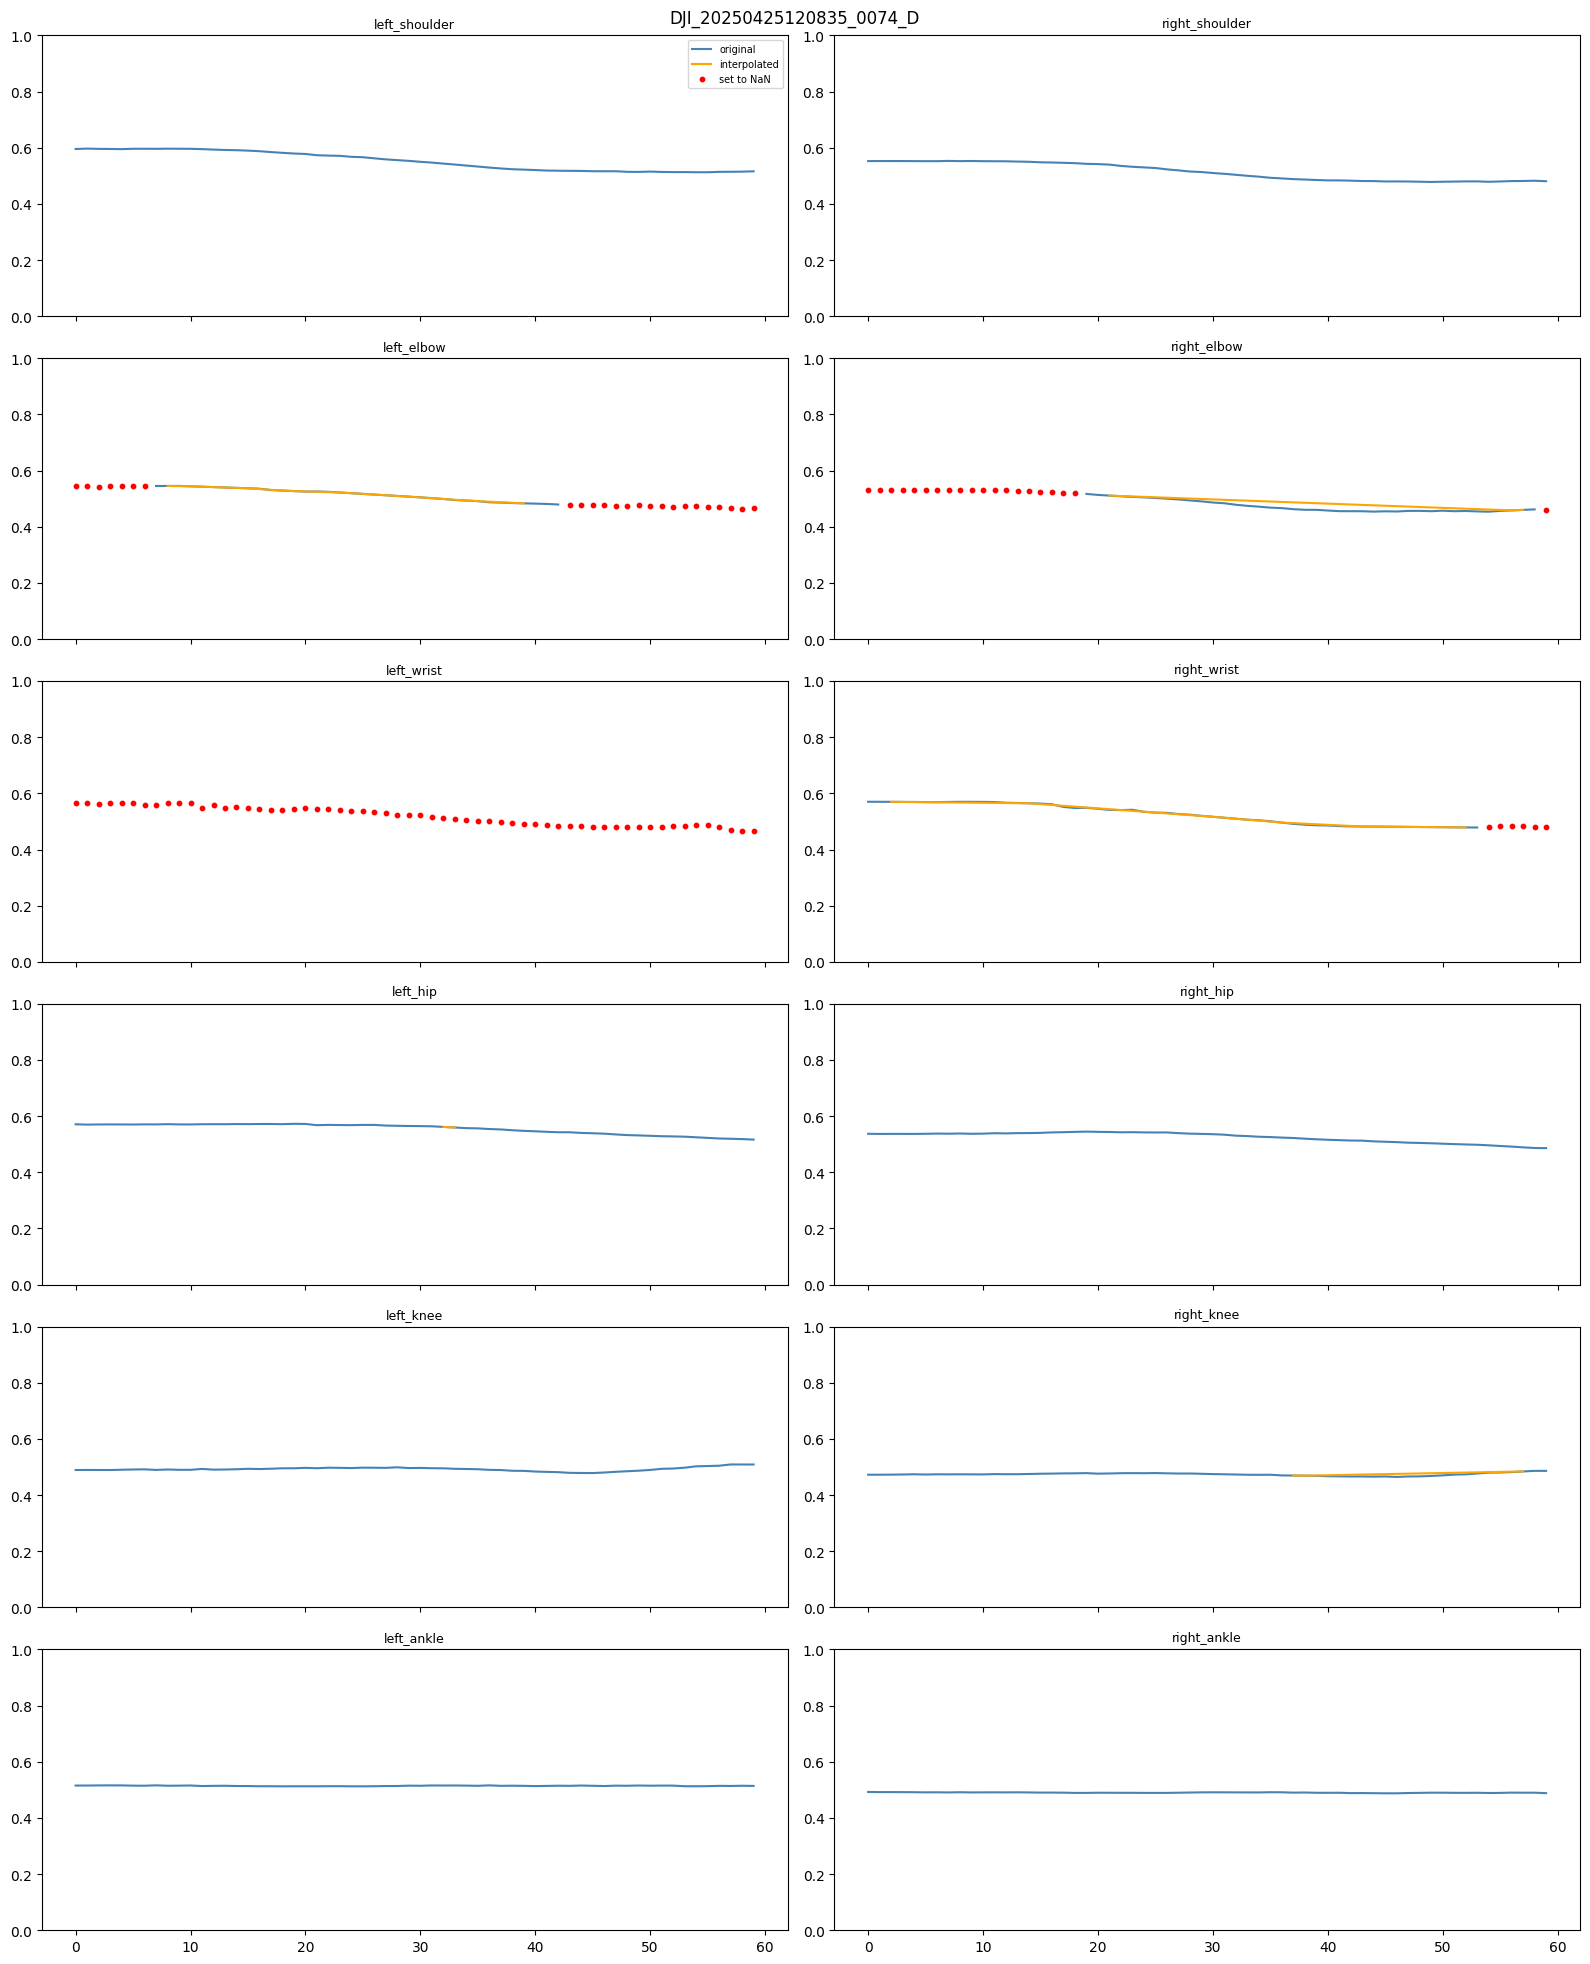

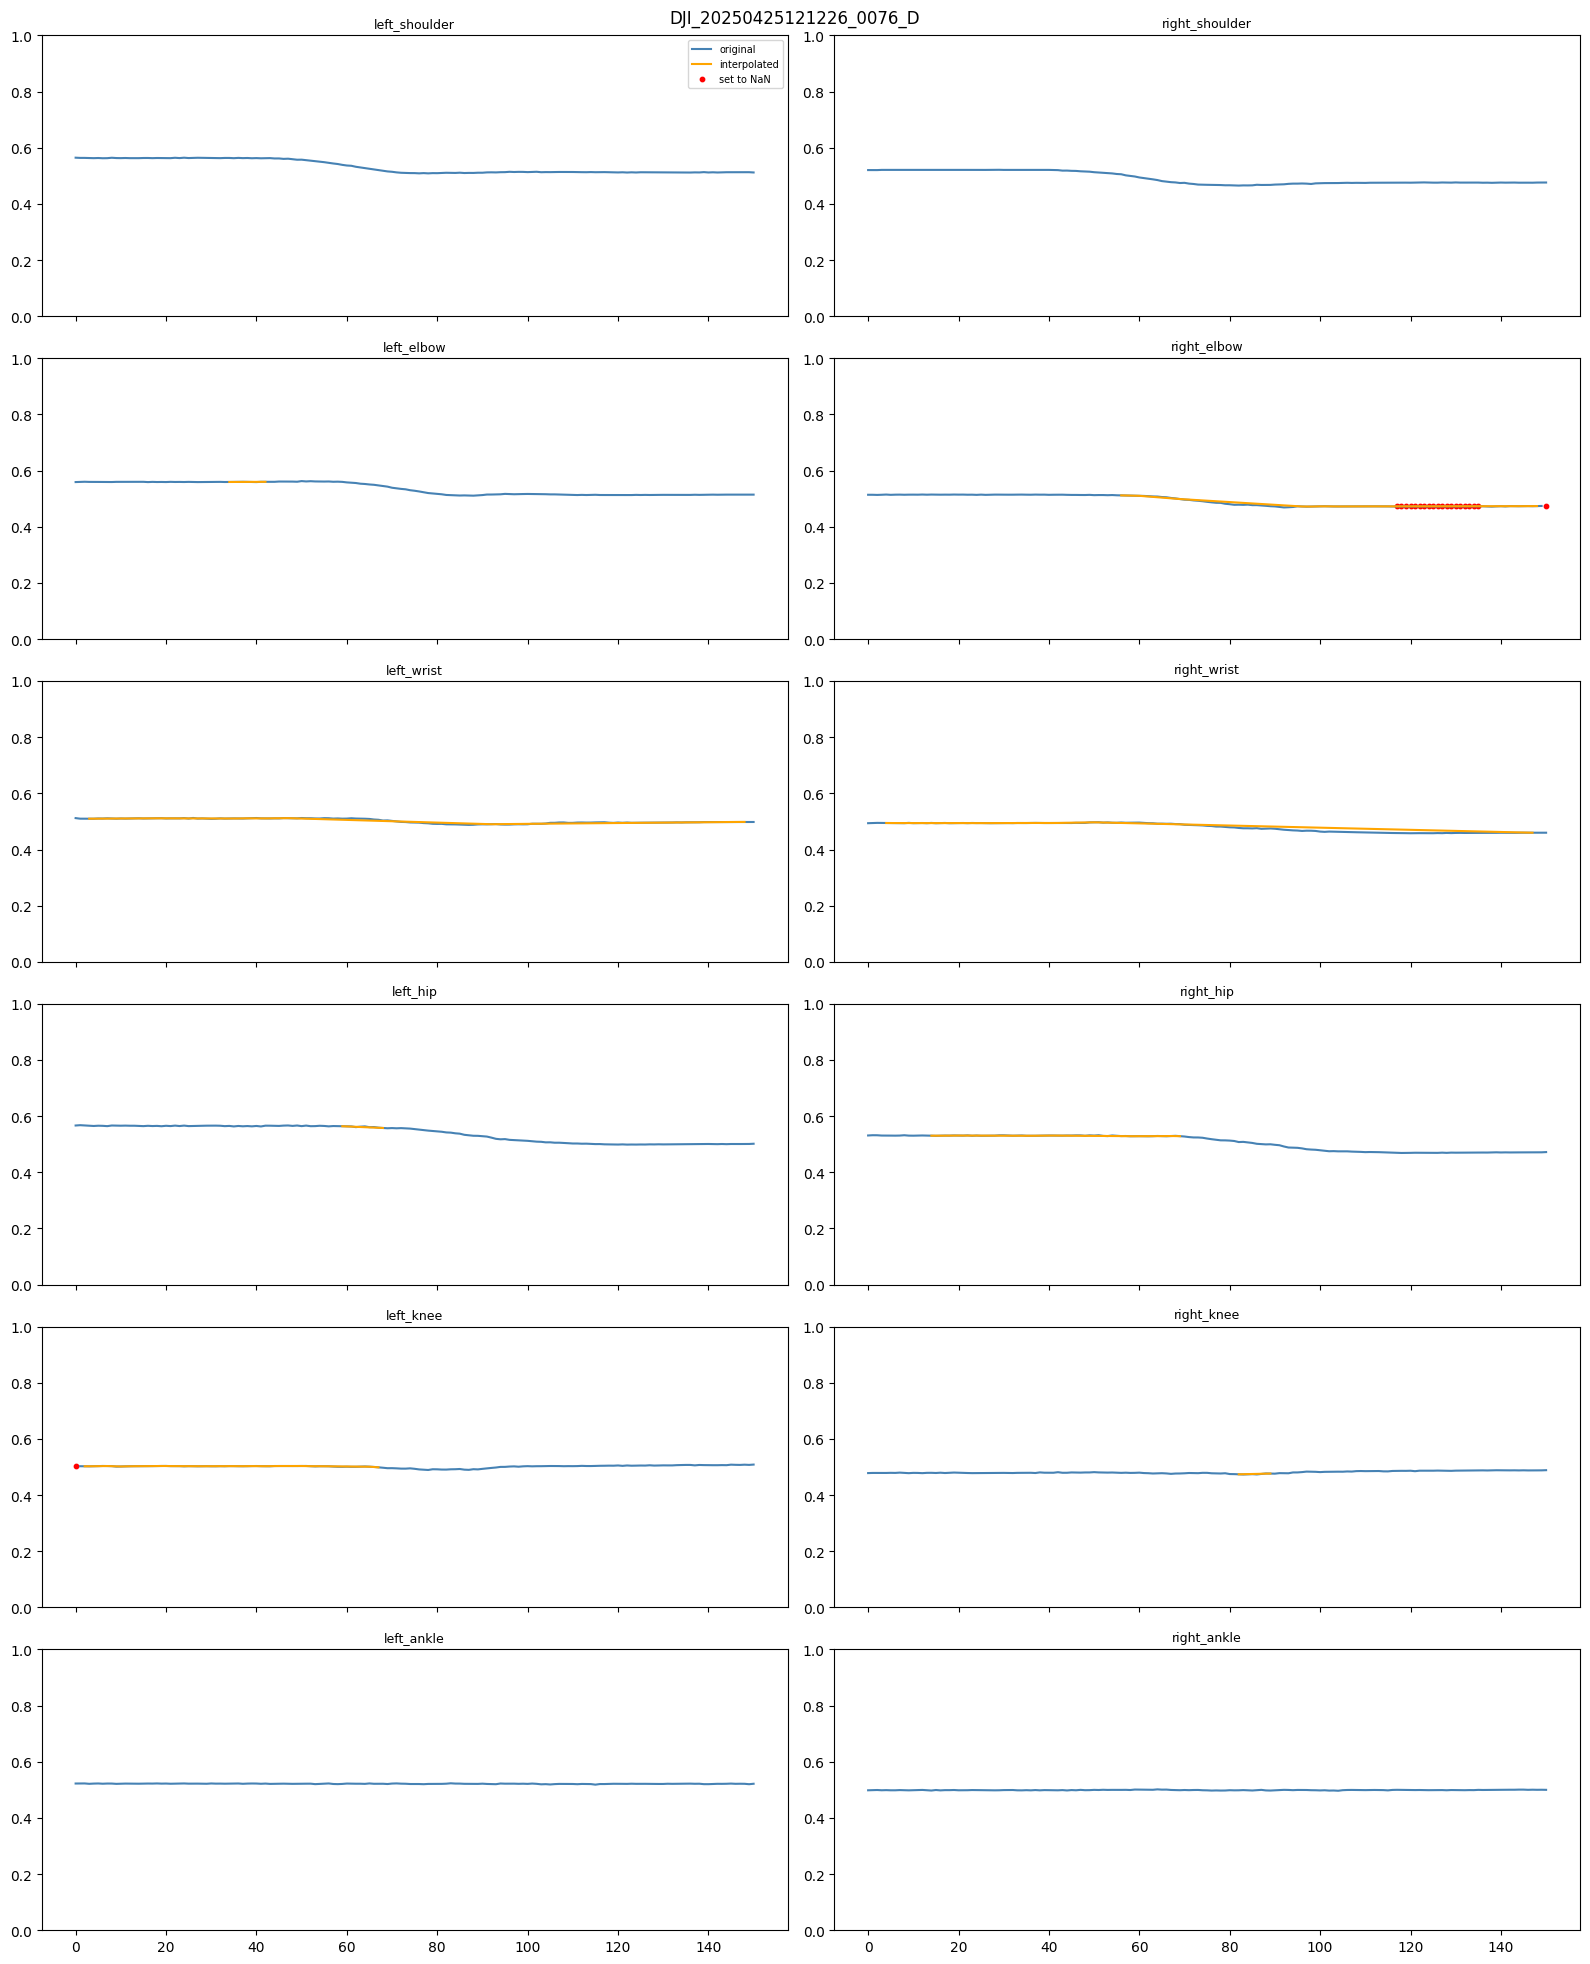

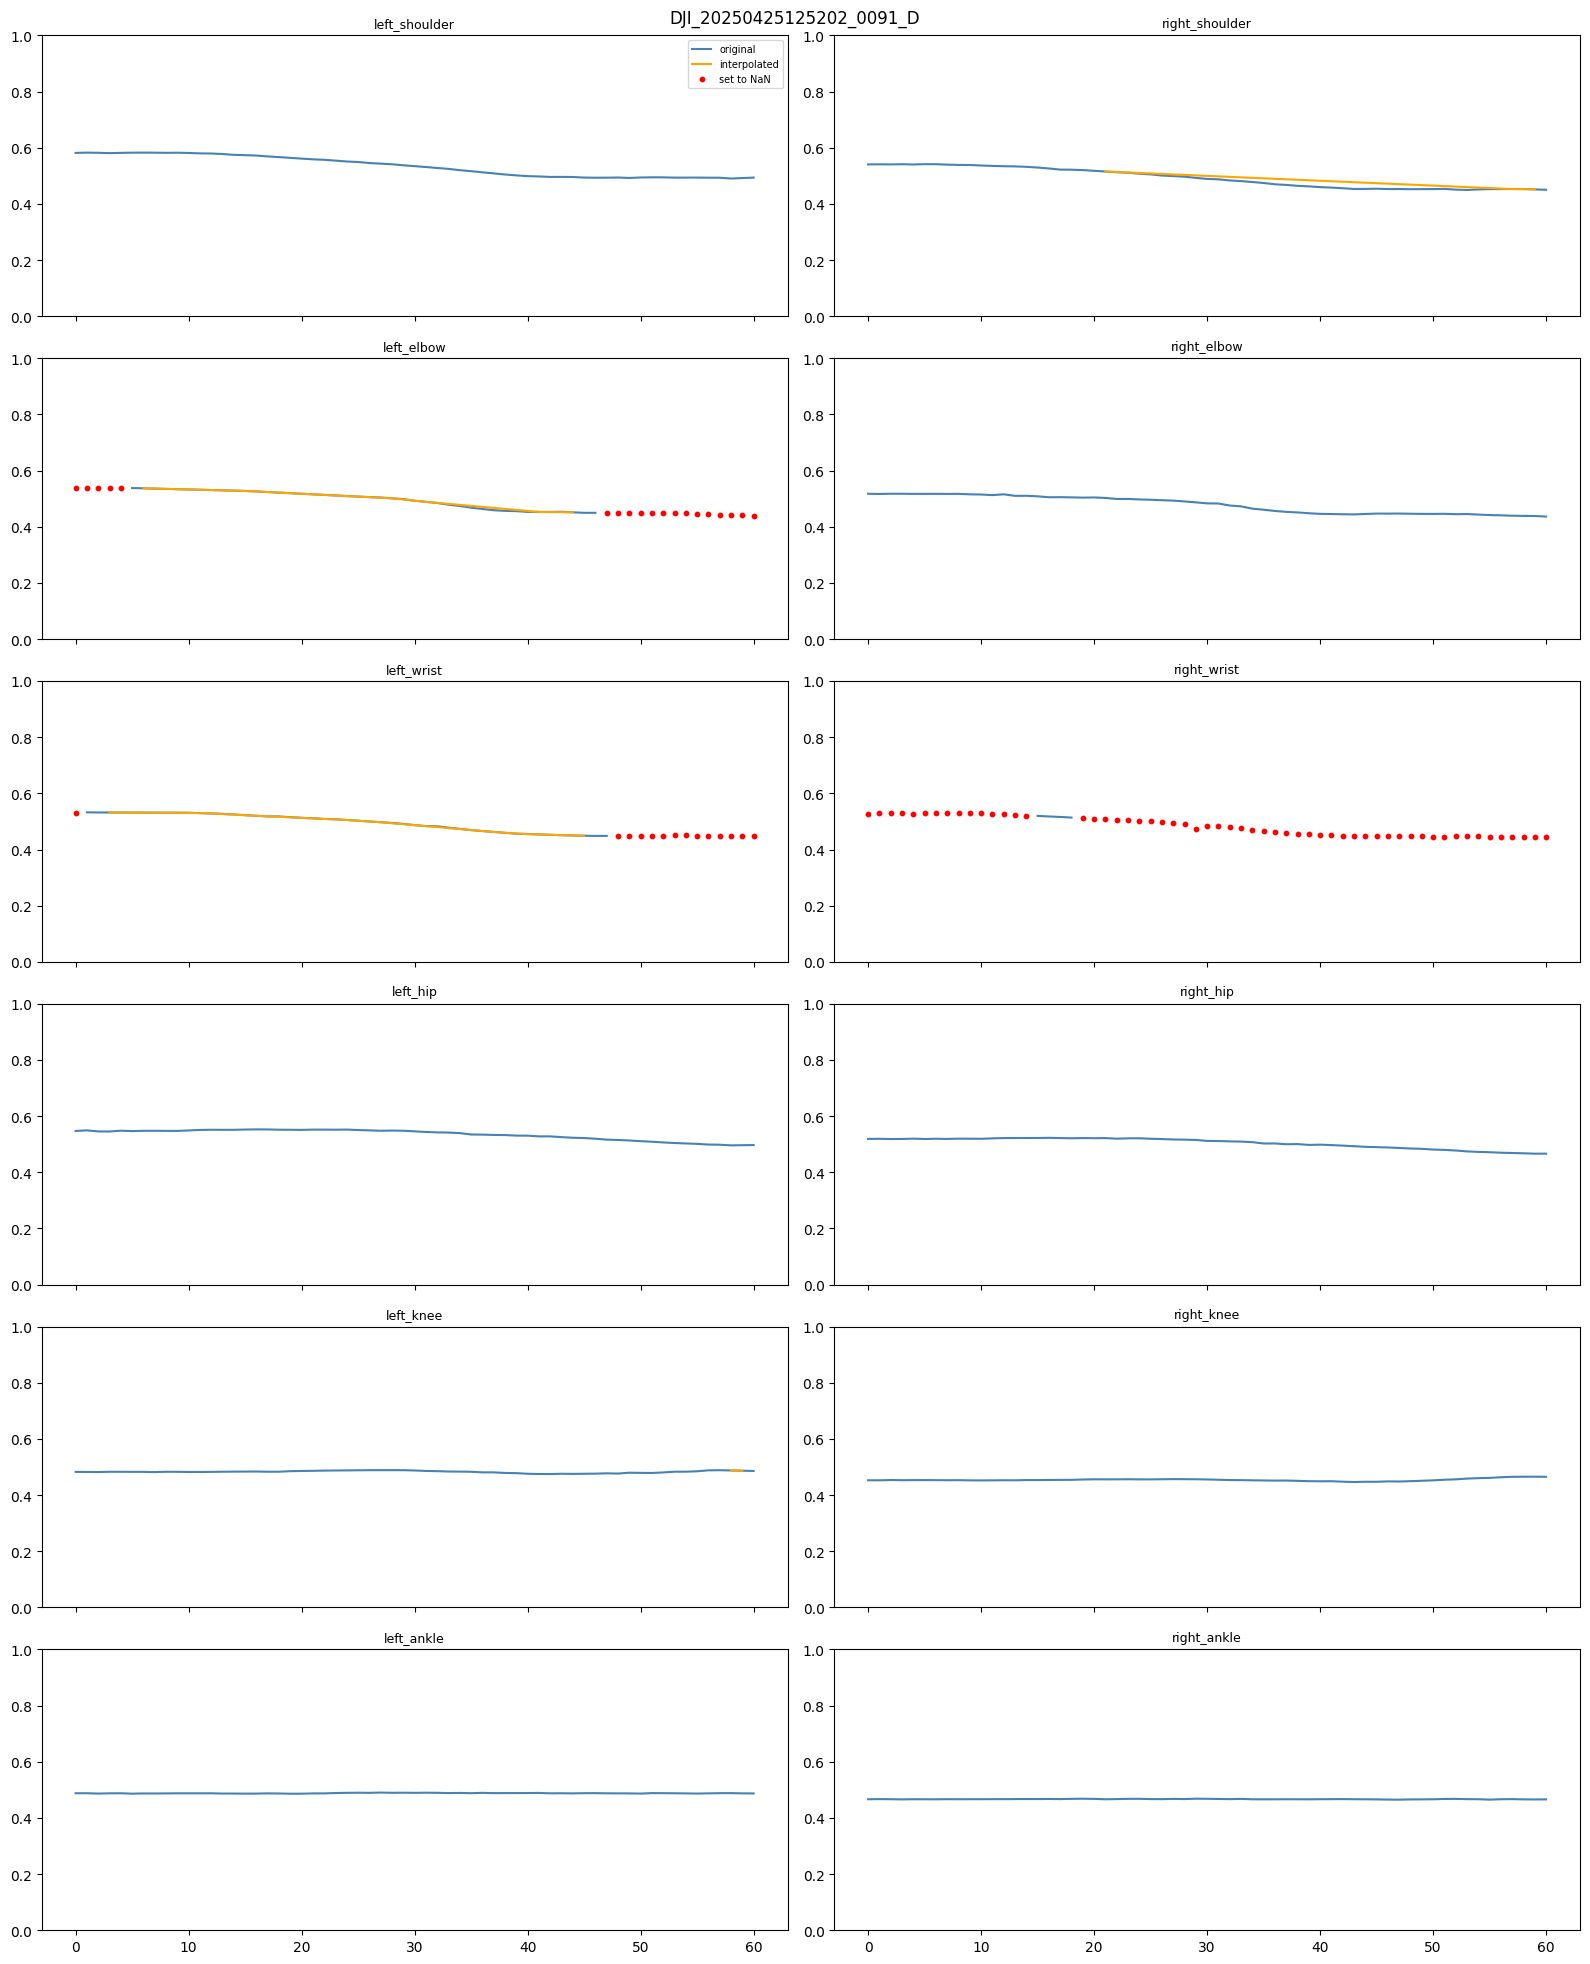

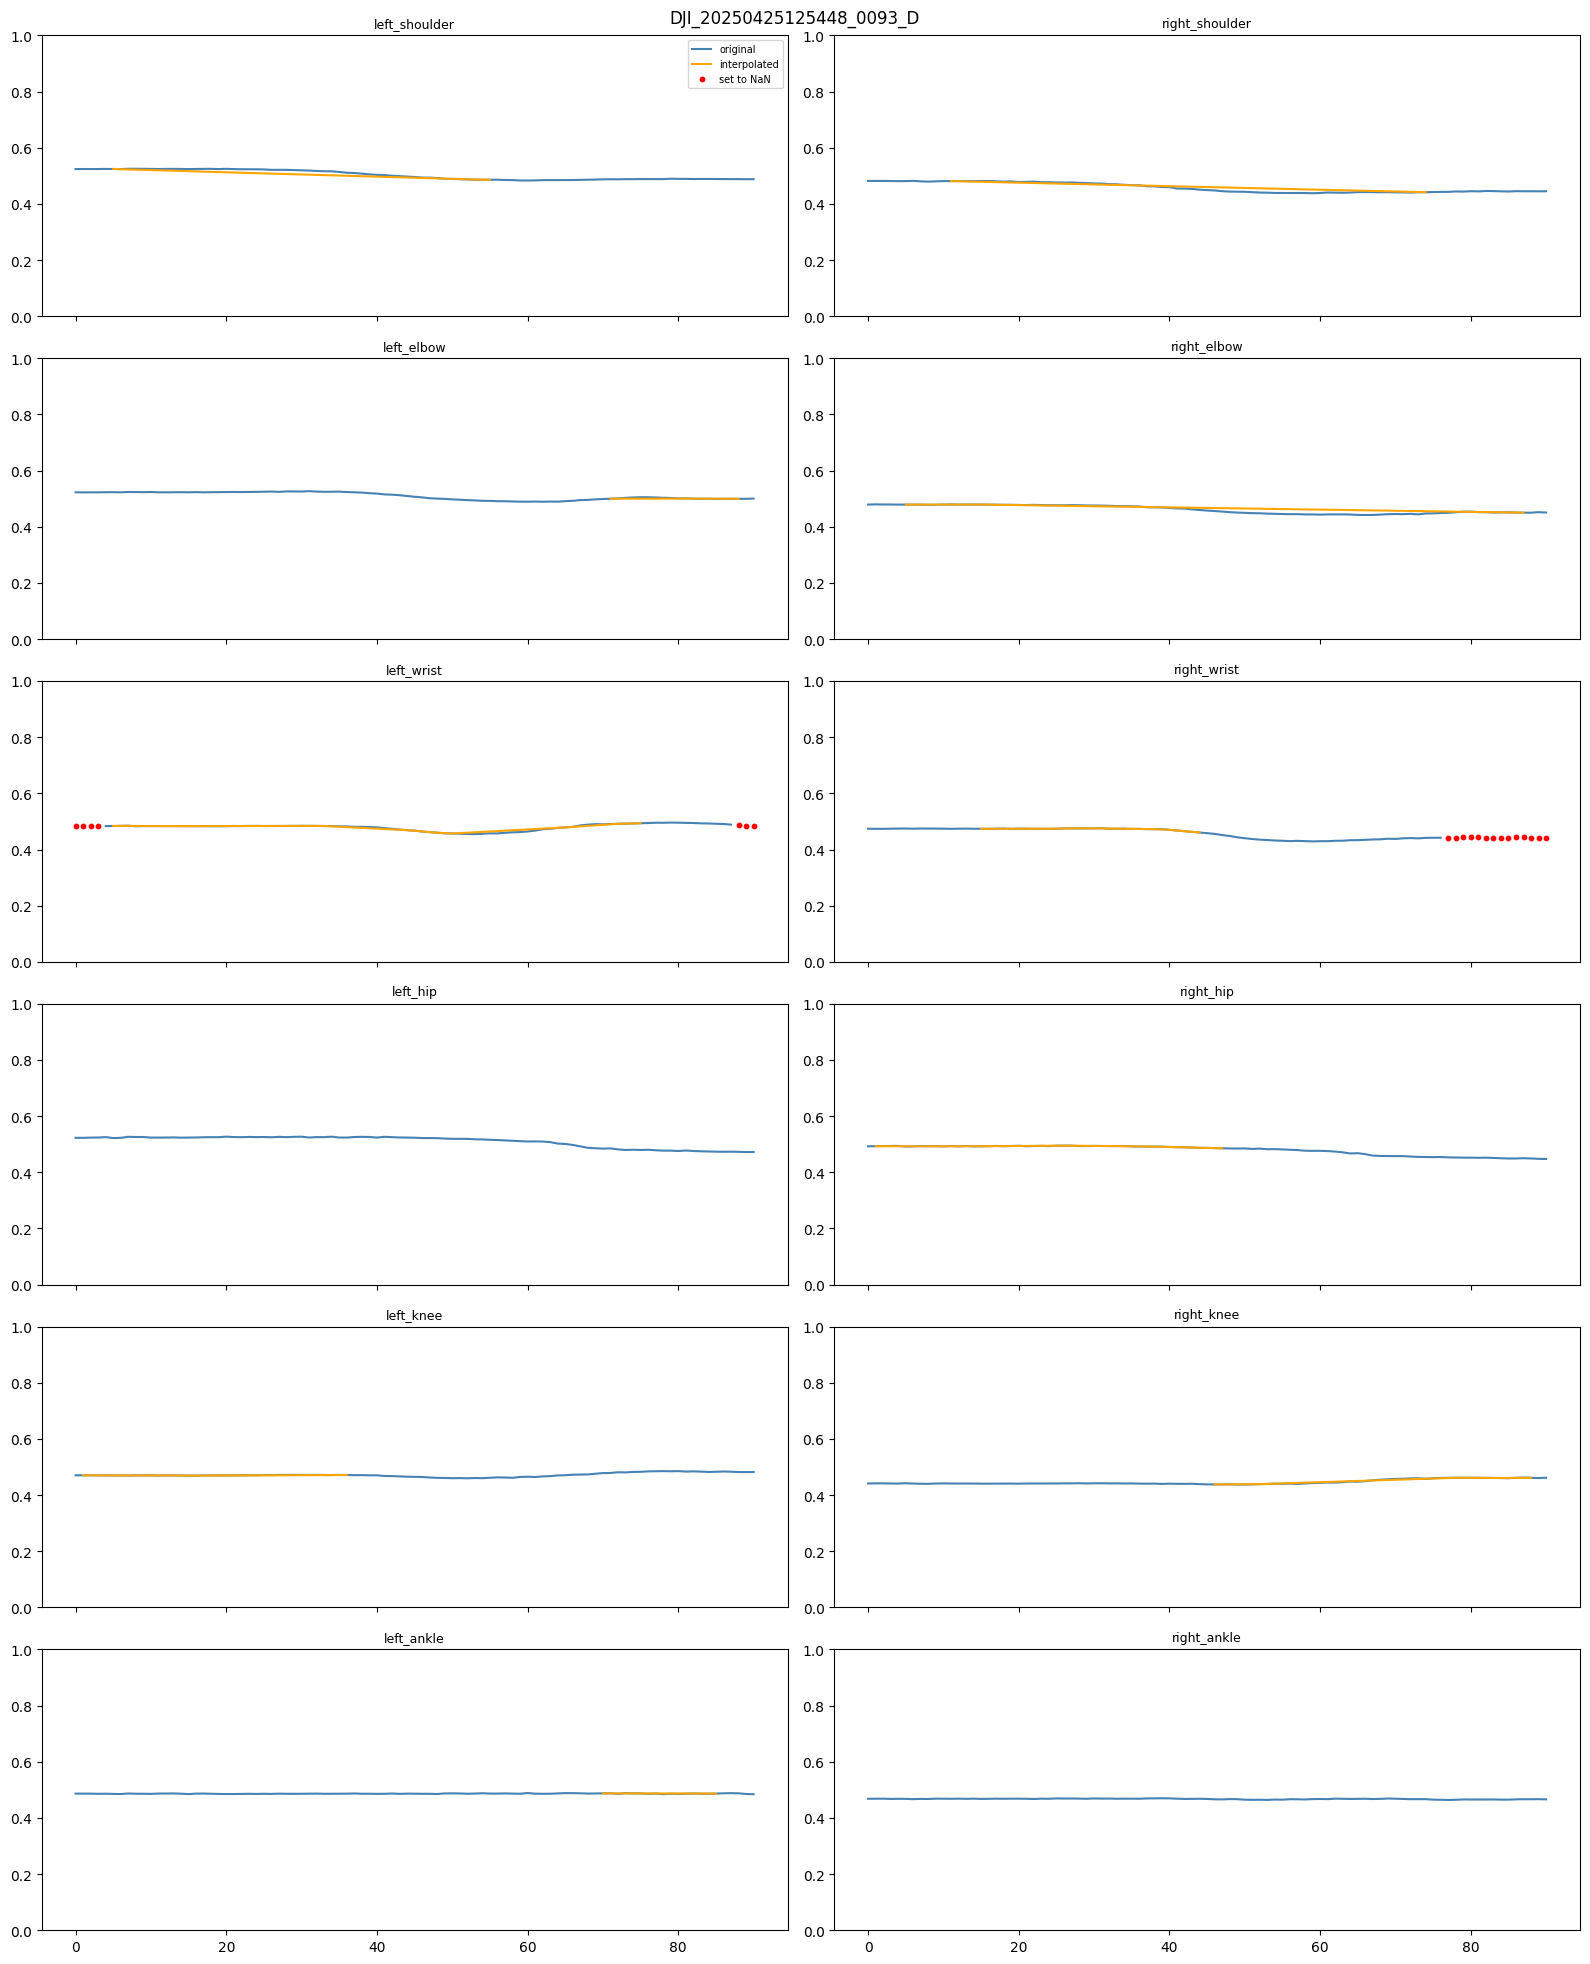

In [153]:
for kp_path in sorted(KEYPOINT_DIR.glob('*.csv')):
    df_orig   = pd.read_csv(kp_path).reset_index(drop=True)
    df_interp = pd.read_csv(OUT_CSV_DIR / kp_path.name).reset_index(drop=True)
    frames    = np.arange(len(df_orig))

    fig, axes = plt.subplots(6, 2, figsize=(16, 20), sharex=True)
    fig.suptitle(kp_path.stem.replace('_movenet', ''), fontsize=12)

    for ax, joint in zip(axes.flatten(), JOINTS):
        conf        = df_orig[f'{joint}_confidence'].values
        x_orig      = df_orig[f'{joint}_x'].values
        x_new       = df_interp[f'{joint}_x'].values
        interpolated = df_interp[f'{joint}_interpolated'].values.astype(bool)

        good     = conf >= THRESHOLD
        nan_mask = (~good) & (~interpolated)

        ax.plot(frames[good],         x_orig[good],          color='steelblue', lw=1.5, label='original')
        ax.plot(frames[interpolated], x_new[interpolated],   color='orange',    lw=1.5, label='interpolated')
        ax.scatter(frames[nan_mask],  x_orig[nan_mask],      color='red', s=10,         label='set to NaN')
        ax.set_title(joint, fontsize=9)
        ax.set_ylim(0, 1)

    axes.flatten()[0].legend(fontsize=7)
    plt.tight_layout()
    plt.show()

## Part C: Video Output

Draw the interpolated skeleton on the original video frames.

- Green dot: confidence >= 0.6 (reliable)
- Orange dot: filled by interpolation
- No dot: NaN

In [154]:
COLOR_GOOD   = (50,  200,  50)
COLOR_INTERP = (0,   165, 255)


def draw_joints(frame, row_orig, row_interp, h, w):
    for joint in JOINTS:
        x = row_interp.get(f'{joint}_x')
        y = row_interp.get(f'{joint}_y')
        if pd.isna(x) or pd.isna(y):
            continue
        color = COLOR_GOOD if row_orig.get(f'{joint}_confidence') >= THRESHOLD else COLOR_INTERP
        cv2.circle(frame, (int(x * w), int(y * h)), 7, color,     -1)
        cv2.circle(frame, (int(x * w), int(y * h)), 7, (0, 0, 0),  1)
    return frame


for csv_path in sorted(KEYPOINT_DIR.glob('*.csv')):
    match = re.search(r'_0(\d{3})_D_movenet', csv_path.stem)
    if not match:
        continue
    vid_id    = match.group(1)
    vid_files = list(VIDEO_DIR.glob(f'*_0{vid_id}_D.MP4'))
    if not vid_files:
        print(f'Video not found: {vid_id}')
        continue

    df_orig   = pd.read_csv(csv_path).reset_index(drop=True)
    df_interp = pd.read_csv(OUT_CSV_DIR / csv_path.name).reset_index(drop=True)
    n_frames  = min(len(df_orig), len(df_interp))

    cap = cv2.VideoCapture(str(vid_files[0]))
    cap.set(cv2.CAP_PROP_POS_FRAMES, int(time_dict[vid_id][0] * FPS))
    w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

    out_name = csv_path.stem.replace('_movenet', '') + '_interpolated.mp4'
    writer   = cv2.VideoWriter(str(OUT_VIDEO_DIR / out_name), cv2.VideoWriter_fourcc(*'avc1'), FPS, (w, h))

    for i in range(n_frames):
        ret, frame = cap.read()
        if not ret:
            break
        writer.write(draw_joints(frame, df_orig.iloc[i], df_interp.iloc[i], h, w))

    cap.release()
    writer.release()
    print(f'{vid_id}: {n_frames} frames -> {out_name}')

028: 94 frames -> DJI_20250425092743_0028_D_interpolated.mp4
030: 92 frames -> DJI_20250425093100_0030_D_interpolated.mp4
045: 73 frames -> DJI_20250425104507_0045_D_interpolated.mp4
047: 94 frames -> DJI_20250425104804_0047_D_interpolated.mp4
059: 123 frames -> DJI_20250425112502_0059_D_interpolated.mp4
061: 151 frames -> DJI_20250425112749_0061_D_interpolated.mp4
074: 60 frames -> DJI_20250425120835_0074_D_interpolated.mp4
076: 151 frames -> DJI_20250425121226_0076_D_interpolated.mp4
091: 61 frames -> DJI_20250425125202_0091_D_interpolated.mp4
093: 91 frames -> DJI_20250425125448_0093_D_interpolated.mp4
